# **REPORT (Final Submission)**


## **Introduction**

In this project we use data from the U.S. _Fatality Analysis Reporting System_ (FARS) and external weather datasets
to investigate how crash risk varies across space, time, and conditions.

Concretely, we:

- Build a reproducible pipeline to download and preprocess FARS data from 1975-2023.
- Enrich annual, state-level crash counts with weather summaries and vehicle miles travelled (VMT).
- Explore relationships between crash rates and weather at the national level.
- Develop a prediction model for the national level (centroids of each country).
- Develop a prediction model for the **Dallas** region using weekly weather data.
- Identify the U.S. city with the most fatal crashes (2015-2023) and then drill down into **Los Angeles** as a case study.
- Finally, we implement three models for the Los Angeles clusters, focusing on cluster-level fatality crashes forecasting within defined geographic areas, and daily fatal-event probability prediction using infrastructure and weather conditions.

The notebook is organised in four main parts:

1. Imports and loading data paths
2. U.S. Country-Level data pipeline and modelling
3. Weather-based modelling for Dallas, Texas
4. Predictive modeling for Los Angeles clusters


## 1. Imports and loading data paths


In [66]:
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
from tqdm import tqdm
import requests
import time
import json
import hashlib
import openmeteo_requests
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import numpy as np
from math import radians, sin, cos, sqrt, atan2
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random
import urllib.request
import urllib.parse
import folium
from folium import plugins
from sklearn.cluster import DBSCAN
from urllib3.util.retry import Retry
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import hdbscan
import plotly.express as px
from plotly.io import write_html
import matplotlib
from folium.plugins import GroupedLayerControl
from sklearn.metrics.pairwise import haversine_distances
import osmnx as ox
from sklearn.neighbors import BallTree
from sklearn.linear_model import PoissonRegressor
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

project_root = Path(os.getcwd()).parents[0]
data_folder = project_root / 'data' / 'data_accidents'
weather_dir = project_root / "data" / "weather_texas_full"
weather_dir.mkdir(parents=True, exist_ok=True)

## 2. U.S. Country-Level data pipeline and modelling


Before running the cells in this notebook make sure you download all the important FARS data by running the **download_fars.py** code inside the **/notebooks** folder, also some of the data needed for the notebook to work is not on github due to the size of the files.

This chapter builds a complete modelling pipeline to estimate how weather patterns influence vehicle crash rates across U.S. states from 2010-2023.

The workflow includes:

- Loading yearly accident datasets
- Aggregating and cleaning crash counts
- Loading VMT (Vehicle Miles Traveled) information
- Fetching daily historical weather data using the Open-Meteo API
- Computing annual weather summaries for each state
- Merging crash, climate, and VMT data
- Engineering features for modelling
- Training predictive models for crash rates and total crashes
- Evaluating model performance with multiple visualizations

This chapter forms the foundation for understanding long-term climatic impacts on transportation safety.


### 2.1. Generate `total_crashes.csv` for each year

Every annual folder inside `data/data_accidents/<YEAR>` contains an `accident.csv` file with individual crash records.  
To create a consistent summary dataset, this step:

1. Iterates through all available year folders 1975-2023
2. Loads the accident dataset for each year
3. Calculates total crashes per state for each year
4. Saves the summary as `total_crashes.csv` in `data/data_accidents` folder


In [2]:
all_years = []

years = sorted([f for f in data_folder.iterdir() if f.is_dir()])

for year_folder in tqdm(years, desc="Processing years", unit="year"):
    year = year_folder.name
    acc_file = year_folder / 'accident.csv'

    if not acc_file.exists():
        continue

    try:
        df = pd.read_csv(acc_file, low_memory=False, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(acc_file, low_memory=False, encoding="latin1")

    if 'STATE' not in df.columns:
        tqdm.write(f"No STATE column found in {year}, skipping")
        continue

    total = df.groupby('STATE').size().reset_index(name='total_crashes')
    total['year'] = int(year)
    total.rename(columns={'STATE': 'state'}, inplace=True)

    all_years.append(total)

df_total = pd.concat(all_years, ignore_index=True)

df_total = df_total.sort_values(["year", "state"])

out_path = data_folder / "total_crashes.csv"
df_total.to_csv(out_path, index=False)

print(f"\nCombined file saved to: {out_path}")

Processing years: 100%|██████████| 53/53 [00:21<00:00,  2.44year/s]


Combined file saved to: c:\Users\zualuk\OneDrive - fer.hr\Desktop\UA\subjects\foundations of data science\project\data-science-pipeline-130275_130318\data\data_accidents\total_crashes.csv


### 2.2. State centroids

Since USA has 51 states and they are really big, it is very challenging to collect weather data. So, to query weather information, each state is represented by a **centorid** with a latitude/longitude coordinate. This section loads a dataset of state geographic centroids, which serve as the input locations for historical weather API requests.


In [3]:
STATE_CENTROIDS = {
    1: (32.3182, -86.9023),   # Alabama
    2: (64.2008, -149.4853),  # Alaska
    4: (34.0489, -111.0937),  # Arizona
    5: (34.7996, -92.1849),   # Arkansas
    6: (37.2719, -119.2702),  # California
    8: (39.5501, -105.7821),  # Colorado
    9: (41.6032, -73.0877),   # Connecticut
    10: (39.1398, -75.5052),  # Delaware
    11: (38.8974, -77.0268),  # District of Columbia
    12: (27.6648, -81.5158),  # Florida
    13: (32.1656, -82.9001),  # Georgia
    15: (19.8968, -155.5828), # Hawaii
    16: (44.0682, -114.7420), # Idaho
    17: (39.7837, -89.6501),  # Illinois
    18: (39.7910, -86.1490),  # Indiana
    19: (41.8780, -93.0977),  # Iowa
    20: (38.5266, -96.7265),  # Kansas
    21: (37.8393, -85.7170),  # Kentucky
    22: (31.2448, -92.1450),  # Louisiana
    23: (45.2538, -69.4455),  # Maine
    24: (39.0458, -76.6413),  # Maryland
    25: (42.4072, -71.3824),  # Massachusetts
    26: (43.3266, -84.5361),  # Michigan
    27: (45.6945, -93.9002),  # Minnesota
    28: (32.3547, -90.0602),  # Mississippi
    29: (38.5443, -92.2884),  # Missouri
    30: (46.9653, -110.0845), # Montana
    31: (41.4925, -99.9018),  # Nebraska
    32: (38.8026, -116.4194), # Nevada
    33: (43.1939, -71.5724),  # New Hampshire
    34: (40.2237, -74.7647),  # New Jersey
    35: (34.5199, -106.0186), # New Mexico
    36: (42.7512, -75.7634),  # New York
    37: (35.7718, -80.0211),  # North Carolina
    38: (47.5515, -100.4659), # North Dakota
    39: (40.4173, -82.9071),  # Ohio
    40: (35.0078, -97.0929),  # Oklahoma
    41: (44.0009, -120.5542), # Oregon
    42: (40.5908, -77.2098),  # Pennsylvania
    44: (41.5801, -71.4774),  # Rhode Island
    45: (33.8361, -81.1637),  # South Carolina
    46: (44.5000, -100.0000), # South Dakota
    47: (35.5175, -86.5804),  # Tennessee
    48: (31.9686, -99.9018),  # Texas
    49: (40.1500, -111.8625), # Utah
    50: (44.5588, -72.5778),  # Vermont
    51: (37.4316, -78.6569),  # Virginia
    53: (47.7511, -120.7401), # Washington
    54: (38.5976, -80.4549),  # West Virginia
    55: (44.5000, -89.5000),  # Wisconsin
    56: (43.0000, -107.5000)  # Wyoming
}

STATE_NAMES = {
    1: "Alabama",
    2: "Alaska",
    4: "Arizona",
    5: "Arkansas",
    6: "California",
    8: "Colorado",
    9: "Connecticut",
    10: "Delaware",
    11: "District of Columbia",
    12: "Florida",
    13: "Georgia",
    15: "Hawaii",
    16: "Idaho",
    17: "Illinois",
    18: "Indiana",
    19: "Iowa",
    20: "Kansas",
    21: "Kentucky",
    22: "Louisiana",
    23: "Maine",
    24: "Maryland",
    25: "Massachusetts",
    26: "Michigan",
    27: "Minnesota",
    28: "Mississippi",
    29: "Missouri",
    30: "Montana",
    31: "Nebraska",
    32: "Nevada",
    33: "New Hampshire",
    34: "New Jersey",
    35: "New Mexico",
    36: "New York",
    37: "North Carolina",
    38: "North Dakota",
    39: "Ohio",
    40: "Oklahoma",
    41: "Oregon",
    42: "Pennsylvania",
    44: "Rhode Island",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    49: "Utah",
    50: "Vermont",
    51: "Virginia",
    53: "Washington",
    54: "West Virginia",
    55: "Wisconsin",
    56: "Wyoming"
}

### 2.3.1. Fetch historical weather data

**This part is commented because you will probably not be able to run it without errors (API KEY LIMITS), but this is how we got the data and later loaded it in the chapter 2.3.2. Yearly aggregation from saved daily data**

Here we retrieve daily historical weather data from the **Open-Meteo API**.  
The pipeline performs the following tasks:

- Initializes a cached HTTP session to avoid repeated API calls
- Queries daily weather variables for each state across all years
- Retrieves climate variables such as:
  - Temperature
  - Precipitation
  - Wind speed

The result is a large daily-resolution dataset of weather conditions for every state centroid from 1975-2023.


In [4]:
# data_folder = project_root / 'data' / 'data_accidents'
# state_full_dir = data_folder / "state_full_json"
# state_full_dir.mkdir(parents=True, exist_ok=True)

# cache_session = requests_cache.CachedSession('.cache', expire_after=86400)
# retry_strategy = Retry(total=5, backoff_factor=0.2)
# retry_session = openmeteo_requests.Client(session=cache_session)
# openmeteo = openmeteo_requests.Client(session=retry_session)

# START_YEAR = 1975
# END_YEAR = 2023

# def fetch_full_period(lat, lon):
#     """Fetch 1975-2023 daily climate data for a single location."""
#     url = "https://climate-api.open-meteo.com/v1/climate"
#     params = {
#         "latitude": lat,
#         "longitude": lon,
#         "start_date": f"{START_YEAR}-01-01",
#         "end_date": f"{END_YEAR}-12-31",
#         "models": "CMCC_CM2_VHR4",
#         "timezone": "UTC",
#         "daily": ["temperature_2m_mean", "precipitation_sum", "wind_speed_10m_mean"]
#     }
#     return openmeteo.weather_api(url, params=params)[0]

# for state_id, (lat, lon) in STATE_CENTROIDS.items():
#     print(f"Fetching full period for state {state_id} ({STATE_NAMES.get(state_id, 'Unknown')})")

#     try:
#         response = fetch_full_period(lat, lon)
#         daily = response.Daily()

#         temp = daily.Variables(0).ValuesAsNumpy()
#         prec = daily.Variables(1).ValuesAsNumpy()
#         wind = daily.Variables(2).ValuesAsNumpy()

#         dates = pd.date_range(
#             start=pd.to_datetime(daily.Time(), unit="s", utc=True),
#             end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
#             freq=pd.Timedelta(seconds=daily.Interval()),
#             inclusive="left"
#         )

#         df_daily = pd.DataFrame({
#             "date": dates.astype(str),
#             "temperature_2m_mean": temp,
#             "precipitation_sum": prec,
#             "wind_speed_10m_mean": wind
#         })

#         out_path = state_full_dir / f"STATE_{state_id}_1975_2023.json"
#         json_obj = {
#             "state_id": state_id,
#             "latitude": lat,
#             "longitude": lon,
#             "years": f"{START_YEAR}-{END_YEAR}",
#             "daily": df_daily.to_dict(orient="records")
#         }
#         with open(out_path, "w") as f:
#             json.dump(json_obj, f, indent=2)

#     except Exception as e:
#         print(f"Failed to fetch or save data for state {state_id}: {e}")
#         continue

# print("Daily data fetching completed and saved to state_full_json/")

### 2.3.2. Yearly aggregation from saved daily data


This step reconstructs the yearly climate summaries (state_yearly_1975_2023.jsonl) directly from the already-downloaded daily JSON files in state_full_json/.


In [6]:
data_folder = project_root / 'data' / 'data_accidents'
state_full_dir = data_folder / "state_full_json"
state_yearly_dir = data_folder / "state_yearly_json"
state_yearly_dir.mkdir(exist_ok=True)

yearly_records = []

for json_path in sorted(state_full_dir.glob("STATE_*.json")):
    with open(json_path, "r") as f:
        data = json.load(f)

    state_id = data["state_id"]
    lat = data["latitude"]
    lon = data["longitude"]

    try:
        df_daily = pd.DataFrame(data["daily"])
        df_daily["date"] = pd.to_datetime(df_daily["date"], utc=True)
        df_daily["year"] = df_daily["date"].dt.year

        df_yearly = df_daily.groupby("year").agg({
            "temperature_2m_mean": "mean",
            "precipitation_sum": "sum",
            "wind_speed_10m_mean": "mean"
        }).reset_index()

        for _, row in df_yearly.iterrows():
            yearly_records.append({
                "state_id": int(state_id),
                "year": int(row["year"]),
                "avg_temp_c": float(row["temperature_2m_mean"]),
                "total_precip_mm": float(row["precipitation_sum"]),
                "avg_wind_speed_ms": float(row["wind_speed_10m_mean"]),
                "latitude": float(lat),
                "longitude": float(lon)
            })
        print(f"Processed state {state_id} ({STATE_NAMES.get(state_id, 'Unknown')})")

    except Exception as e:
        print(f"Error processing {json_path.name}: {e}")

yearly_jsonl_path = state_yearly_dir / "state_yearly_1975_2023.jsonl"
with open(yearly_jsonl_path, "w") as f:
    for rec in yearly_records:
        f.write(json.dumps(rec) + "\n")

print(f"\nRebuilt yearly file with {len(yearly_records)} records.")

Processed state 10 (Delaware)
Processed state 11 (District of Columbia)
Processed state 12 (Florida)
Processed state 13 (Georgia)
Processed state 15 (Hawaii)
Processed state 16 (Idaho)
Processed state 17 (Illinois)
Processed state 18 (Indiana)
Processed state 19 (Iowa)
Processed state 1 (Alabama)
Processed state 20 (Kansas)
Processed state 21 (Kentucky)
Processed state 22 (Louisiana)
Processed state 23 (Maine)
Processed state 24 (Maryland)
Processed state 25 (Massachusetts)
Processed state 26 (Michigan)
Processed state 27 (Minnesota)
Processed state 28 (Mississippi)
Processed state 29 (Missouri)
Processed state 2 (Alaska)
Processed state 30 (Montana)
Processed state 31 (Nebraska)
Processed state 32 (Nevada)
Processed state 33 (New Hampshire)
Processed state 34 (New Jersey)
Processed state 35 (New Mexico)
Processed state 36 (New York)
Processed state 37 (North Carolina)
Processed state 38 (North Dakota)
Processed state 39 (Ohio)
Processed state 40 (Oklahoma)
Processed state 41 (Oregon)


### 2.4. Combining crashes and weather data into `final_accidents.csv`


In [7]:
data_folder = project_root / 'data' / 'data_accidents'
yearly_jsonl_path = data_folder / "state_yearly_json" / "state_yearly_1975_2023.jsonl"
crashes_csv_path = data_folder / "total_crashes.csv"

climate_records = []
with open(yearly_jsonl_path, "r") as f:
    for line in f:
        climate_records.append(json.loads(line))

df_climate = pd.DataFrame(climate_records)
print("Climate sample:")
display(df_climate.head())

df_crashes = pd.read_csv(crashes_csv_path)
print("Crashes sample:")
display(df_crashes.head())


df_crashes = df_crashes.rename(columns={"state": "state_id"})

df_final = df_crashes.merge(
    df_climate,
    on=["state_id", "year"],
    how="left"
)

df_state_names = pd.DataFrame(list(STATE_NAMES.items()), columns=["state_id", "state_name"])
df_final = df_final.merge(df_state_names, on="state_id", how="left")

df_final = df_final[[
    "state_name", "state_id", "year", "total_crashes",
    "avg_temp_c", "total_precip_mm", "avg_wind_speed_ms",
    "latitude", "longitude"
]]

print("Merged sample, df_final:")
display(df_final.head())

output_path = data_folder / "final_accidents.csv"
df_final.to_csv(output_path, index=False)

print("Saved updated dataset with state names to:", output_path)

Climate sample:


,state_id,year,avg_temp_c,total_precip_mm,avg_wind_speed_ms,latitude,longitude
0,10,1975,12.906438,1017.069263,12.961904,39.1398,-75.5052
1,10,1976,13.627232,1100.685402,13.234289,39.1398,-75.5052
2,10,1977,12.884253,966.260549,12.369622,39.1398,-75.5052
3,10,1978,12.866049,976.530282,12.680079,39.1398,-75.5052
4,10,1979,12.935753,762.913501,13.340200,39.1398,-75.5052


Crashes sample:


,state,total_crashes,year
0,1,765,1975
1,2,98,1975
2,4,593,1975
3,5,475,1975
4,6,3667,1975


Merged sample, df_final:


,state_name,state_id,year,total_crashes,avg_temp_c,total_precip_mm,avg_wind_speed_ms,latitude,longitude
0,Alabama,1,1975,765,18.289002,778.931329,8.879612,32.3182,-86.9023
1,Alaska,2,1975,98,-3.858101,395.137084,8.587646,64.2008,-149.4853
2,Arizona,4,1975,593,13.881677,500.400255,7.351995,34.0489,-111.0937
3,Arkansas,5,1975,475,17.206208,948.870567,10.324337,34.7996,-92.1849
4,California,6,1975,3667,4.178099,945.074420,5.709918,37.2719,-119.2702


Saved updated dataset with state names to: c:\Users\zualuk\OneDrive - fer.hr\Desktop\UA\subjects\foundations of data science\project\data-science-pipeline-130275_130318\data\data_accidents\final_accidents.csv


### 2.5. Download & load VMT data


Why VMT (Vehicle Miles Traveled)?

So far, our dataset `final_accidents.csv` contains the total number of fatal crashes per state and year, along with weather and geographic features. While this is useful, it has a critical limitation: Total crashes are driven largely by how much people drive, not just by how dangerous driving conditions are.

For example, California consistently reports more fatal crashes than Wyoming - but this is mostly because far more miles are driven in California.

To isolate the true effect of weather on crash risk, we need to account for exposure: the total amount of driving occurring in a state each year.

In transportation safety research, the standard metric for exposure is **Vehicle Miles Traveled (VMT) - the total number of miles driven by all vehicles in a state during a year.**

We use VMT to compute the **fatal crash rate**:

$$
\text{Crash Rate} = \frac{\text{Total Fatal Crashes}}{\text{VMT}} \times 100{,}000{,}000
$$

This gives us **fatal crashes per 100 million vehicle miles traveled** - the **official safety metric** used by the U.S. Department of Transportation (DOT), NHTSA, and FHWA.


Our model will capture whether hotter, wetter, or windier years actually make **each mile driven more dangerous**.
Just a small note: **We have VMT data for each state from 1980 until 2023**


In [8]:
project_root = Path(os.getcwd()).parents[0]
vmt_folder = project_root / "data" / "vmt"
data_acc_folder = project_root / "data" / "data_accidents"
vmt_raw_path = vmt_folder / "VMT_original.csv"
accidents_path = data_acc_folder / "final_accidents.csv"
output_path = data_acc_folder / "final_accidents_with_vmt.csv"

df_vmt_raw = pd.read_csv(vmt_raw_path)
df_vmt_total = df_vmt_raw.groupby(['Year', 'State'])['VMT'].sum().reset_index()
df_vmt_total.rename(columns={'Year': 'year', 'State': 'state_name', 'VMT': 'vmt'}, inplace=True)

NAME_TO_FIPS = {name: fips for fips, name in STATE_NAMES.items()}

df_vmt_total['state_id'] = df_vmt_total['state_name'].map(NAME_TO_FIPS)
unmapped = df_vmt_total[df_vmt_total['state_id'].isna()]['state_name'].unique()
if len(unmapped) > 0:
    print(f"\nWarning: These states were not mapped to FIPS codes: {unmapped}")
else:
    print("\nAll states successfully mapped to FIPS codes")

df_vmt_total = df_vmt_total.dropna(subset=['state_id'])
df_vmt_total['state_id'] = df_vmt_total['state_id'].astype(int)

### 2.6. Merge VMT with accident data


In [10]:
data_folder = project_root / 'data' / 'data_accidents'
final_csv_path = data_folder / "final_accidents.csv"
df_final = pd.read_csv(final_csv_path)

df_vmt_total['state_id'] = df_vmt_total['state_id'].astype(int)
df_acc = df_final.copy()
df_acc['state_id'] = df_acc['state_id'].astype(int)

df_final = pd.merge(
    df_acc,
    df_vmt_total[['state_id', 'year', 'vmt']],
    on=['state_id', 'year'],
    how='inner'  
)

print(f"\nSuccessfully merged, final shape: {df_final.shape}")
print("Years covered:", df_final['year'].min(), "to", df_final['year'].max())
print("States covered:", df_final['state_name'].nunique())
print("\ndf_final:")
df_final.head()


Successfully merged, final shape: (2244, 10)
Years covered: 1980 to 2023
States covered: 51

df_final:


,state_name,state_id,year,total_crashes,avg_temp_c,total_precip_mm,avg_wind_speed_ms,latitude,longitude,vmt
0,Alabama,1,1980,835,18.045027,1235.245319,8.992018,32.3182,-86.9023,2.902700e+10
1,Alaska,2,1980,79,-1.734674,466.319275,8.910187,64.2008,-149.4853,2.665000e+09
2,Arizona,4,1980,833,13.420449,758.078563,7.187392,34.0489,-111.0937,1.793100e+10
3,Arkansas,5,1980,486,16.949563,855.259530,9.794807,34.7996,-92.1849,1.623200e+10
4,California,6,1980,4930,3.937228,1035.248370,5.442434,37.2719,-119.2702,1.558900e+11


### 2.7. Compute crash rate per 100 million VMT

After computing crash rate per 100 million VMT, the data is merged with accident data and saved into: `data/data_accidents/final_accidents_with_vmt.csv`


In [11]:
df_final['crash_rate_per_100m_vmt'] = (df_final['total_crashes'] / df_final['vmt']) * 100_000_000
df_final = df_final[df_final['vmt'] > 0].reset_index(drop=True)

print("\nCrash rate computed! Sample:")
print(df_final[['state_name', 'year', 'total_crashes', 'vmt', 'crash_rate_per_100m_vmt']].head())

output_path = project_root / "data" / "data_accidents" / "final_accidents_with_vmt.csv"
df_final.to_csv(output_path, index=False)

print(f"Final dataset saved successfully to:\n{output_path}")
print(f"Dataset shape: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")


Crash rate computed! Sample:
   state_name  year  total_crashes           vmt  crash_rate_per_100m_vmt
0     Alabama  1980            835  2.902700e+10                 2.876632
1      Alaska  1980             79  2.665000e+09                 2.964353
2     Arizona  1980            833  1.793100e+10                 4.645586
3    Arkansas  1980            486  1.623200e+10                 2.994086
4  California  1980           4930  1.558900e+11                 3.162486
Final dataset saved successfully to:
c:\Users\zualuk\OneDrive - fer.hr\Desktop\UA\subjects\foundations of data science\project\data-science-pipeline-130275_130318\data\data_accidents\final_accidents_with_vmt.csv
Dataset shape: (2244, 11)
Columns: ['state_name', 'state_id', 'year', 'total_crashes', 'avg_temp_c', 'total_precip_mm', 'avg_wind_speed_ms', 'latitude', 'longitude', 'vmt', 'crash_rate_per_100m_vmt']


### _Visualizing the national crash rate trend (1980-2023)_


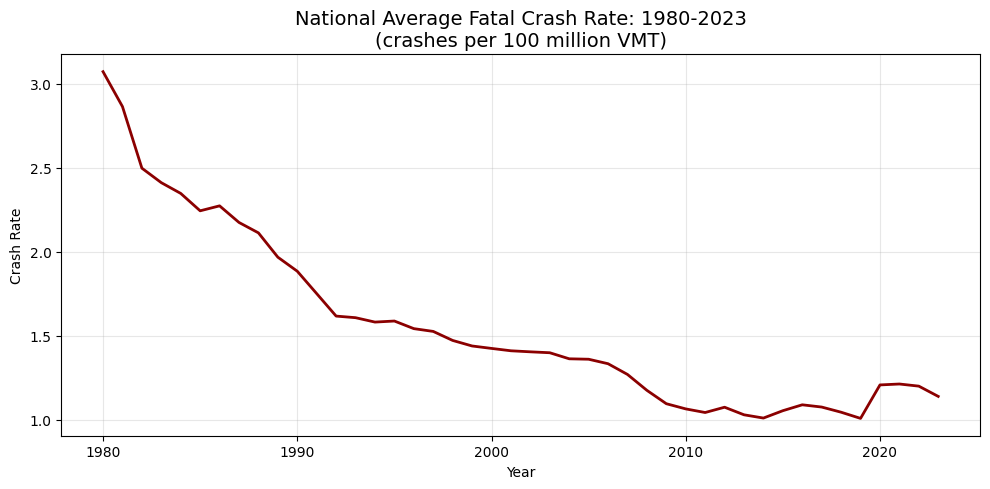

In [12]:
project_root = Path(os.getcwd()).parents[0]
df = pd.read_csv(project_root / "data" / "data_accidents" / "final_accidents_with_vmt.csv")

national_trend = df.groupby('year')['crash_rate_per_100m_vmt'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(national_trend['year'], national_trend['crash_rate_per_100m_vmt'],
         color='darkred', linewidth=2)
plt.title('National Average Fatal Crash Rate: 1980-2023\n(crashes per 100 million VMT)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Crash Rate')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The fatal crash rate per 100 million vehicle miles traveled (VMT) has **declined dramatically** since the 1980s - dropping from over 3.0 to around 1.1-1.2 in recent years.

This reflects decades of progress in automotive safety, including seat belts, airbags, anti-lock brakes, automated emergency braking, stricter drunk-driving laws, and improved road design. Despite rising vehicle miles traveled and increased distractions (e.g., smartphones), the risk per mile driven has fallen by nearly 65%.

After decades of decline, the fatal crash rate began rising again, with a notable increase by 2018, likely due to distracted driving, larger vehicles, and more extreme weather.


### _Crash rate vs. average temperature_

This visualization explores the relationship between a state's average yearly temperature and its crash rate.  
Each point represents a state-year observation, and the scatter cloud shows the overall distribution.

A regression line is added to try to highlight the general trend. This helps reveal whether warmer or cooler climates are associated with higher crash risk, providing an initial look at how temperature may influence driving safety.


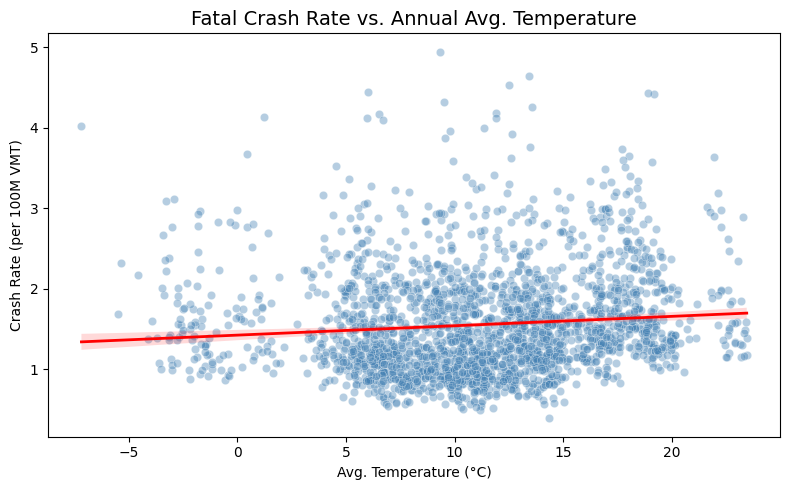

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='avg_temp_c',
    y='crash_rate_per_100m_vmt',
    alpha=0.4,
    color='steelblue'
)
sns.regplot(
    data=df,
    x='avg_temp_c',
    y='crash_rate_per_100m_vmt',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)
plt.title('Fatal Crash Rate vs. Annual Avg. Temperature', fontsize=14)
plt.xlabel('Avg. Temperature (°C)')
plt.ylabel('Crash Rate (per 100M VMT)')
plt.tight_layout()
plt.show()

The plot shows a very weak positive relationship between average temperature and fatal crash rates. Higher temperatures are associated with a modest increase in fatal crashes, but the relationship is very weak and likely influenced by many other factors, which we will look at.


### _Taking a deeper look at some countries_


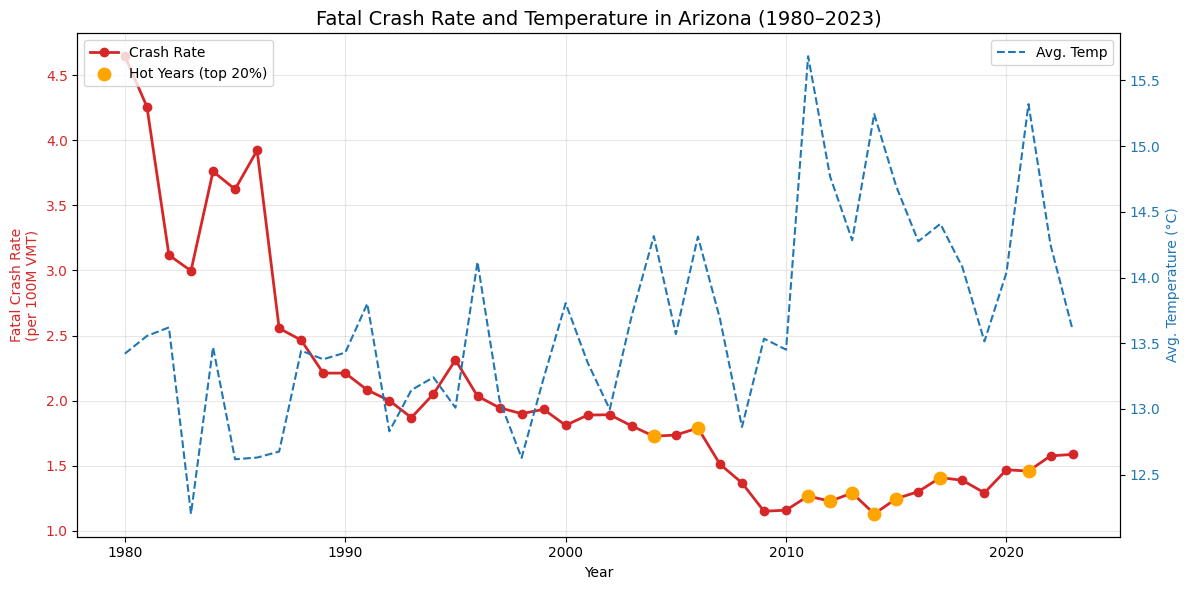

In [15]:
STATE = "Arizona"

state_data = df[df['state_name'] == STATE].copy()
state_data = state_data.sort_values('year')

fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('Fatal Crash Rate\n(per 100M VMT)', color=color)
ax1.plot(state_data['year'], state_data['crash_rate_per_100m_vmt'],
         color=color, marker='o', linewidth=2, label='Crash Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Avg. Temperature (°C)', color=color)
ax2.plot(state_data['year'], state_data['avg_temp_c'],
         color=color, linestyle='--', linewidth=1.5, label='Avg. Temp')
ax2.tick_params(axis='y', labelcolor=color)

hot_threshold = state_data['avg_temp_c'].quantile(0.8)  # top 20% hottest
hot_years = state_data[state_data['avg_temp_c'] >= hot_threshold]
ax1.scatter(hot_years['year'], hot_years['crash_rate_per_100m_vmt'],
            color='orange', s=80, zorder=5, label='Hot Years (top 20%)')

plt.title(f'Fatal Crash Rate and Temperature in {STATE} (1980–2023)', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
fig.tight_layout()
plt.show()

This graph shows how the fatal crash rate (per 100 million vehicle miles traveled) and average annual temperature have changed over time in a single U.S. state - for example, Arizona - from 1980 to 2023. The red line represents the state’s yearly fatal crash risk, while the blue dashed line shows the average temperature for that same year. Orange dots highlight the state’s hottest years (top 20% of temperatures during this period).

We can see that Arizona’s fatal crash rate has generally declined. Although temperatures have trended upward over time and several of the hottest years are marked, there is no strong or consistent pattern showing that hotter years correspond to notably higher fatal crash rates. Some hot years align with slightly elevated crash rates, but others occur during relatively low-risk periods.

Overall, the relationship between temperature and fatal crash risk in Arizona appears weak and inconsistent. Long-term improvements in vehicle safety, road engineering, and enforcement likely play a larger role in shaping the downward trend in fatal crash rates than annual fluctuations in temperature.


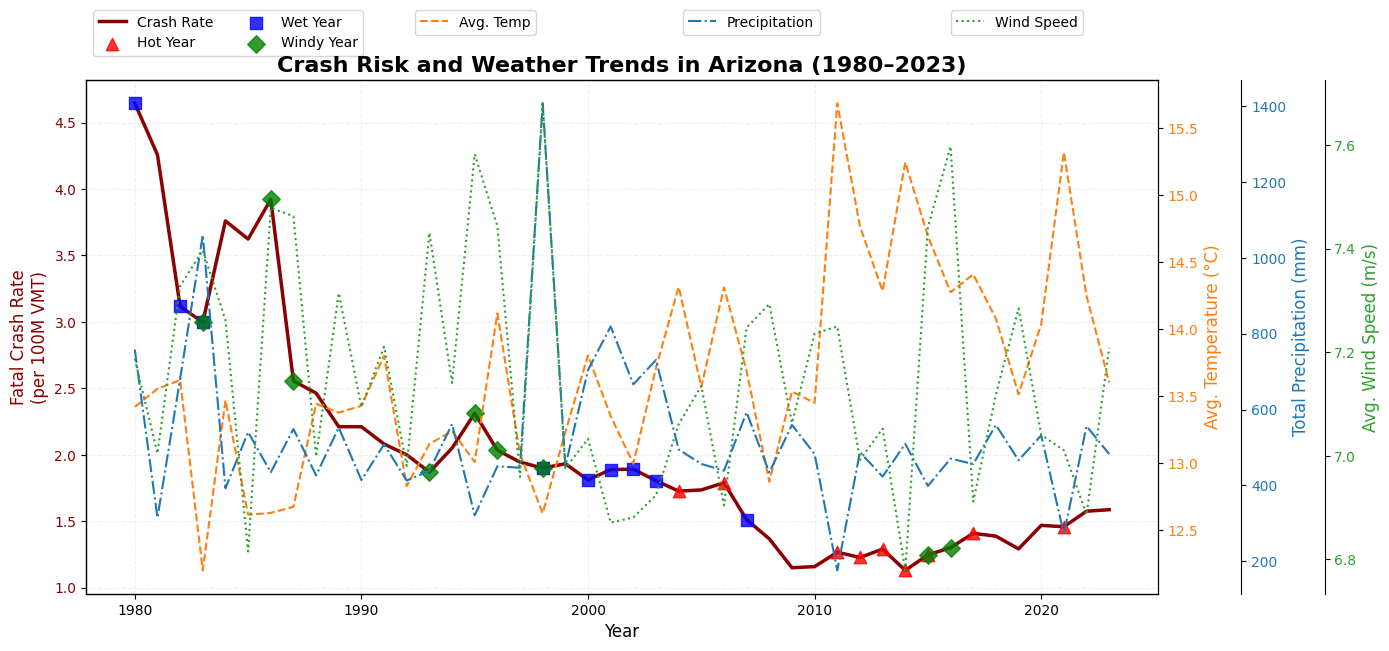

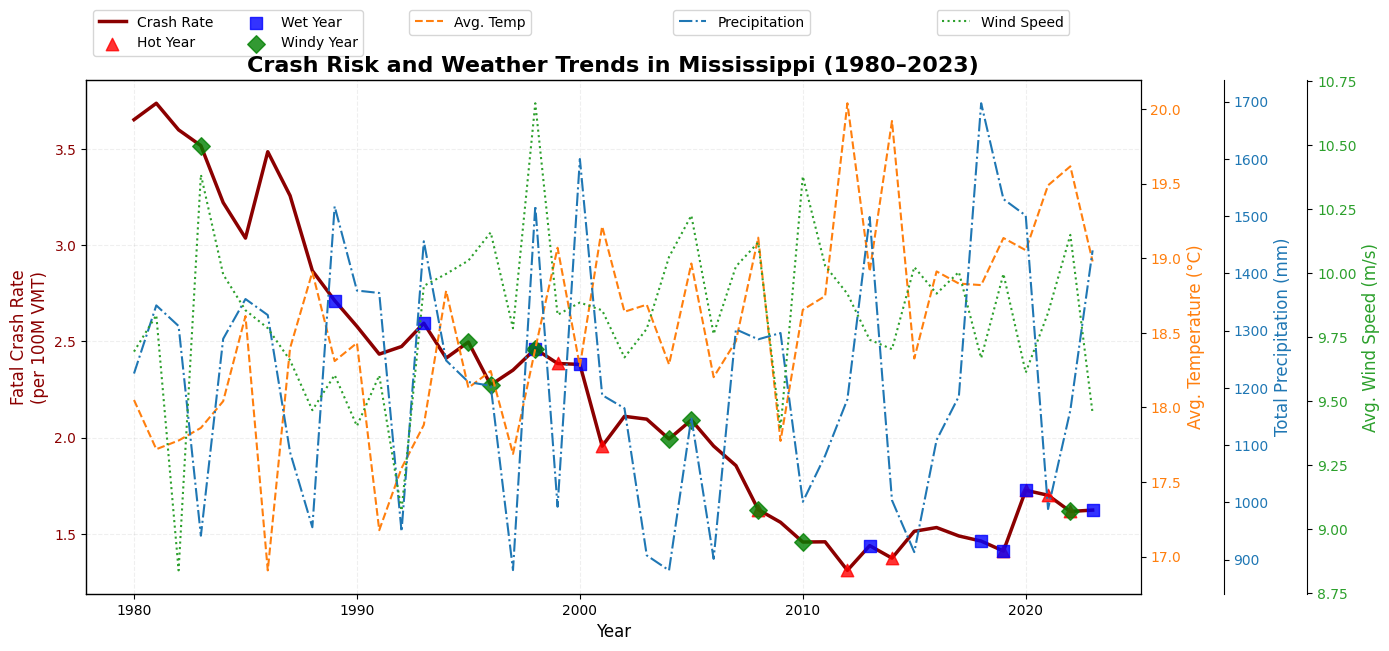

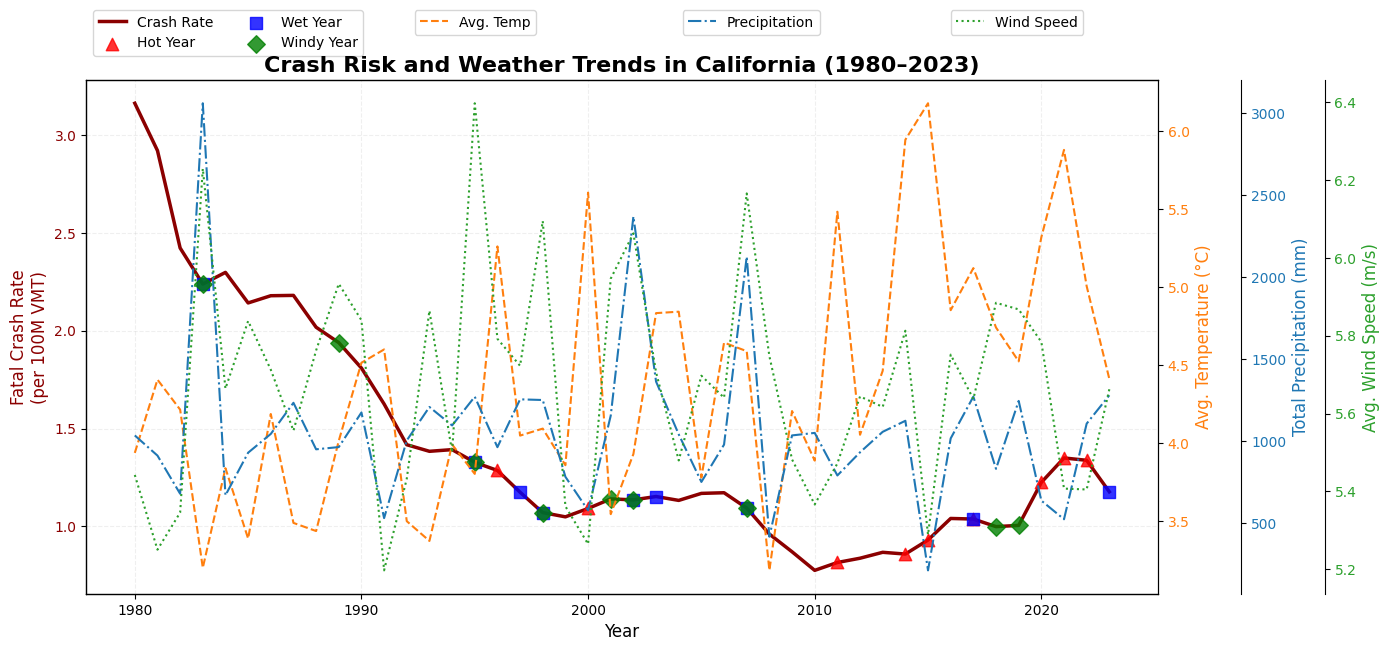

In [16]:
def plot_weather_crash_trends(df, state_name):
    state_data = df[df['state_name'] == state_name].sort_values('year').copy()

    if state_data.empty:
        print(f"No data found for state: {state_name}")
        return

    temp_threshold = state_data['avg_temp_c'].quantile(0.8)
    precip_threshold = state_data['total_precip_mm'].quantile(0.8)
    wind_threshold = state_data['avg_wind_speed_ms'].quantile(0.8)

    state_data['is_hot'] = state_data['avg_temp_c'] >= temp_threshold
    state_data['is_wet'] = state_data['total_precip_mm'] >= precip_threshold
    state_data['is_windy'] = state_data['avg_wind_speed_ms'] >= wind_threshold

    fig, ax1 = plt.subplots(figsize=(14, 7))

    color_crash = 'darkred'
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Fatal Crash Rate\n(per 100M VMT)', color=color_crash, fontsize=12)
    ax1.plot(state_data['year'], state_data['crash_rate_per_100m_vmt'],
             color=color_crash, linewidth=2.5, label='Crash Rate', zorder=5)
    ax1.tick_params(axis='y', labelcolor=color_crash)
    ax1.grid(alpha=0.2, linestyle='--')

    ax2 = ax1.twinx()
    color_temp = 'tab:orange'
    ax2.set_ylabel('Avg. Temperature (°C)', color=color_temp, fontsize=12)
    ax2.plot(state_data['year'], state_data['avg_temp_c'],
             color=color_temp, linewidth=1.5, linestyle='--', label='Avg. Temp')
    ax2.tick_params(axis='y', labelcolor=color_temp)

    ax3 = ax1.twinx()
    color_precip = 'tab:blue'
    ax3.spines['right'].set_position(('outward', 60))  
    ax3.set_ylabel('Total Precipitation (mm)', color=color_precip, fontsize=12)
    ax3.plot(state_data['year'], state_data['total_precip_mm'],
             color=color_precip, linewidth=1.5, linestyle='-.', label='Precipitation')
    ax3.tick_params(axis='y', labelcolor=color_precip)

    ax4 = ax1.twinx()
    color_wind = 'tab:green'
    ax4.spines['right'].set_position(('outward', 120))  
    ax4.set_ylabel('Avg. Wind Speed (m/s)', color=color_wind, fontsize=12)
    ax4.plot(state_data['year'], state_data['avg_wind_speed_ms'],
             color=color_wind, linewidth=1.5, linestyle=':', label='Wind Speed')
    ax4.tick_params(axis='y', labelcolor=color_wind)

    ax1.scatter(state_data[state_data['is_hot']]['year'],
                state_data[state_data['is_hot']]['crash_rate_per_100m_vmt'],
                color='red', s=80, marker='^', label='Hot Year', alpha=0.8, zorder=6)

    ax1.scatter(state_data[state_data['is_wet']]['year'],
                state_data[state_data['is_wet']]['crash_rate_per_100m_vmt'],
                color='blue', s=80, marker='s', label='Wet Year', alpha=0.8, zorder=6)

    ax1.scatter(state_data[state_data['is_windy']]['year'],
                state_data[state_data['is_windy']]['crash_rate_per_100m_vmt'],
                color='green', s=80, marker='D', label='Windy Year', alpha=0.8, zorder=6)

    plt.title(f'Crash Risk and Weather Trends in {state_name} (1980–2023)', fontsize=16, fontweight='bold')
    ax1.legend(loc='upper left', bbox_to_anchor=(0, 1.15), ncol=2)
    ax2.legend(loc='upper left', bbox_to_anchor=(0.3, 1.15), ncol=1)
    ax3.legend(loc='upper left', bbox_to_anchor=(0.55, 1.15), ncol=1)
    ax4.legend(loc='upper left', bbox_to_anchor=(0.8, 1.15), ncol=1)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_weather_crash_trends(df, "Arizona")
plot_weather_crash_trends(df, "Mississippi")
plot_weather_crash_trends(df, "California")

This graph displays the year-by-year evolution of fatal crash risk (red line) alongside three weather variables - average temperature (orange), total precipitation (blue), and average wind speed (green) - for a single state over nearly 50 years. Each weather variable is plotted on its own vertical axis to avoid overlap, while crash rate remains on the primary axis for direct comparison. Extreme years - defined as the hottest, wettest, or windiest 20% of years - are marked with distinct symbols: triangles for heat, squares for rain, and diamonds for wind. By examining this visualization, we can identify whether specific weather extremes consistently coincide with spikes in crash risk. For example, if a very wet year (blue square) aligns with a peak in crash rate, it suggests heavy precipitation may increase collision risk.

But again we can see that there is not much correlation between any of the weather variables and fatal crash rate.


### 2.8. Modeling the relationship between weather and fatal crash risk


Now that we have a clean, integrated dataset (final_accidents_with_vmt.csv) spanning 1980–2023, we can formally test whether weather conditions are statistically associated with fatal crash risk, after accounting for state-specific safety trends and time effects.


We focus on the fatal crash rate per 100 million VMT as our target variable, since it controls for exposure (i.e., how much people drive). This allows us to ask: **_“Do hotter, wetter, or windier years make each mile driven more dangerous?”_**


To understand whether weather actually affects crash risk, we need to compare the same state across different years, rather than comparing, for example, Arizona to Minnesota. That’s because states differ in many permanent ways (like road layouts, traffic laws, or driving habits) that also affect safety, and those differences could misleadingly look like “weather effects.”
So instead, we ask: “In Texas, do years with hotter temperatures tend to have higher crash rates than cooler years in Texas?” We do this for every state, then combine the results. This approach cancels out each state’s fixed traits and isolates the link between yearly changes in weather and yearly changes in crash risk within the same state.


In [17]:
project_root = Path(os.getcwd()).parents[0]
df = pd.read_csv(project_root / "data" / "data_accidents" / "final_accidents_with_vmt.csv")

df = df[(df['year'] >= 1980) & (df['year'] <= 2023)].copy()
df['state_id'] = df['state_id'].astype('category')
df['year_centered'] = df['year'] - df['year'].mean()

print(f"Loaded {len(df)} state-year observations from {df['year'].min()} to {df['year'].max()}")

Loaded 2244 state-year observations from 1980 to 2023


#### Standardizing Weather Variables

We standardize the three weather predictors: `avg_temp_c`, `total_precip_mm`, and `avg_wind_speed_ms`, so that each has a mean of 0 and a standard deviation of 1.

**Why?**

- These variables are measured on very different scales (e.g., temperature in °C, precipitation in mm, wind in m/s).
- Standardization ensures that their regression coefficients are **directly comparable**: a coefficient of 0.10 means “a one-standard-deviation increase in this weather variable is associated with a 0.10-point increase in crash rate.”
- It also improves numerical stability during estimation.


In [22]:
weather_cols = ['avg_temp_c', 'total_precip_mm', 'avg_wind_speed_ms']
df[weather_cols] = StandardScaler().fit_transform(df[weather_cols])

#### Full Model Specification

To isolate the true relationship between weather and fatal crash risk, we estimate the following fixed-effects regression model:

$$
\text{CrashRate}_{s,t} = \beta_1 \cdot \text{Temp}_{s,t} + \beta_2 \cdot \text{Precip}_{s,t} + \beta_3 \cdot \text{Wind}_{s,t} + \gamma \cdot \text{Year}_t + \alpha_s + \varepsilon_{s,t}
$$

Where:

- **$\text{CrashRate}_{s,t}$** = fatal crashes per 100 million VMT in state $s$ and year $t$
- **Weather variables** are annual state-level averages, standardized to mean = 0, std = 1
- **$\text{Year}_t$** = centered calendar year (to capture long-term safety trends)
- **$\alpha_s$** = state fixed effects (one intercept per state)
- **$\varepsilon_{s,t}$** = error term, with **robust (HC3) standard errors** to account for heteroskedasticity

#### Why this design?

- **State fixed effects** remove all time-invariant differences between states (e.g., road design, enforcement culture, urbanization), so we only use **within-state year-to-year variation** to identify weather effects.
- **Year control** ensures we don’t mistake the 65% national decline in crash risk (1980-2023) for a weather signal.
- **Robust standard errors** guarantee valid inference despite unequal variance across states (e.g., noisier rates in low-VMT states like Wyoming).

This approach is standard in policy and transportation research for drawing **causal-like conclusions from observational panel data**.


In [23]:
formula = (
    "crash_rate_per_100m_vmt ~ "
    "avg_temp_c + total_precip_mm + avg_wind_speed_ms + "
    "year_centered + C(state_id)"
)

print("Fitting fixed-effects regression model...")
model_fe = smf.ols(formula=formula, data=df).fit(cov_type='HC3')
print("Model fitted")

Fitting fixed-effects regression model...
Model fitted


In [24]:
weather_and_time = ['avg_temp_c', 'total_precip_mm', 'avg_wind_speed_ms', 'year_centered']
print(model_fe.params[weather_and_time].to_frame("Coefficient"))
print("\nStandard Errors:")
print(model_fe.bse[weather_and_time].to_frame("SE"))
print("\nP-values:")
print(model_fe.pvalues[weather_and_time].to_frame("P-value"))

alpha = 0.05
significant = model_fe.pvalues[weather_and_time] < alpha
print(f"\nSignificant at α = {alpha}?")
print(significant.to_frame("Significant"))

                   Coefficient
avg_temp_c            0.204277
total_precip_mm      -0.004621
avg_wind_speed_ms     0.011520
year_centered        -0.038225

Standard Errors:
                         SE
avg_temp_c         0.055853
total_precip_mm    0.017683
avg_wind_speed_ms  0.054133
year_centered      0.000764

P-values:
                    P-value
avg_temp_c         0.000255
total_precip_mm    0.793861
avg_wind_speed_ms  0.831470
year_centered      0.000000

Significant at α = 0.05?
                   Significant
avg_temp_c                True
total_precip_mm          False
avg_wind_speed_ms        False
year_centered             True


#### Regression Results: Weather and Fatal Crash Risk (Fixed-Effects Model)

We estimate the association between annual weather conditions and the fatal crash rate (per 100 million VMT) using a state fixed-effects model that controls for long-term trends and permanent state differences.

| Variable            | Coefficient | Std. Error | P-value | Significant (α = 0.05)? |
| ------------------- | ----------- | ---------- | ------- | ----------------------- |
| `avg_temp_c`        | +0.204      | 0.056      | 0.0003  | Yes                     |
| `total_precip_mm`   | –0.005      | 0.018      | 0.794   | No                      |
| `avg_wind_speed_ms` | +0.012      | 0.054      | 0.831   | No                      |
| `year_centered`     | –0.038      | 0.001      | <0.001  | Yes                     |

#### Key Interpretations

- **Temperature**: A **1-standard-deviation increase** in annual average temperature is associated with a **+0.204 increase** in fatal crashes per 100 million VMT. This effect is **highly statistically significant** (p = 0.0003), indicating a reliable link between warmer years and slightly higher crash risk-even after accounting for state-specific safety baselines and time trends.

- **Precipitation & Wind**: Neither total annual precipitation nor average wind speed shows a statistically significant association with crash risk (p > 0.79). Their estimated effects are negligible and statistically indistinguishable from zero.

- **Long-Term Safety Trend**: Crash rates have declined by **0.038 points per year** on average (p < 0.001), reflecting decades of progress in vehicle safety, road design, and policy-consistent with the national trend.


#### Temperature Effects on Fatal Crash Risk

Our model shows that a **one-standard-deviation increase in annual average temperature** is associated with an increase of **0.204 fatal crashes per 100 million vehicle miles traveled (VMT)**, a statistically significant effect (_p_ = 0.0003).

When scaled to a high-VMT state such as California (approximately **308 billion VMT annually**), this corresponds to **on the order of several hundred additional traffic fatalities in unusually warm years**, holding total miles driven, precipitation, wind conditions, state fixed effects, and long-term safety trends constant.

Importantly, this estimate reflects an **upper-bound, linear interpretation** of the regression coefficient. Typical year-to-year temperature fluctuations are substantially smaller than one full standard deviation, implying that the expected impact in most years is considerably lower.

**Conclusion**: We use a fixed-effects panel regression to isolate within-state variation over time, removing both permanent state differences and national safety trends.
After standardizing weather variables, coefficients are directly comparable.
We find that temperature is the only weather variable with a statistically significant association with fatal crash risk, while precipitation and wind show no detectable effects.
The magnitude of the temperature effect is small relative to the long-term downward trend in crash risk, suggesting that weather plays a secondary role compared to infrastructure, behavior, and policy.


## 3. Weather-based modeling for Dallas, Texas


In this chapter we explore a different approach to understanding how weather affects traffic fatalities. Instead of summarizing each year into a single set of values, we work with detailed daily accident and weather records to build a richer view of short-term conditions. However, the **model itself uses weekly aggregated data**, because weekly patterns are more stable and less noisy than day-by-day counts, giving the model a more reliable signal to learn from.

The main idea is to capture short-term effects of weather on safety that might be lost in annual averages while avoiding the extreme randomness of daily fatal crash data. This allows us to study:

- how weekly patterns in temperature, precipitation, wind, snowfall, cloud cover, and humidity relate to fatal crashes
- whether extreme weather has immediate, short-term impacts
- whether multiple localized geographic points improve predictive accuracy

We also experiment on a single state - **Texas** - and represent it using **five key county centroids**, which capture the major climate regions and provide more realistic local weather conditions:

- **Dallas** - North Texas (storms, cooler winters)
- **El Paso** - West Texas (dry, desert climate)
- **Austin** - Central Texas (transition zone between wet and dry regions)
- **Houston** - Gulf Coast (humid, heavy rainfall, tropical storms)
- **San Antonio** - South Texas (hotter, semi-arid conditions)

Working with all five points provides better geographic coverage, but processing each one requires a separate full daily merge. For this demonstration, we use **only the Dallas region**, because the process is identical for all other locations and can be easily reused when expanding the analysis.


### 3.1. Fetching daily weather data for Dallas


In [ ]:
POINT_NAME = "DALLAS"
DALLAS_LAT = 32.7767
DALLAS_LON = -96.7970

START_YEAR = 1975
END_YEAR = 2023

cache_session = requests_cache.CachedSession(".cache", expire_after=86400)
retry_session = retry(cache_session, retries=5, backoff_factor=0.3)
openmeteo = openmeteo_requests.Client(session=retry_session)

def fetch_full_period(lat, lon):
    url = "https://climate-api.open-meteo.com/v1/climate"
    
    daily_params = [
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "wind_speed_10m_mean",
        "wind_speed_10m_max",
        "cloud_cover_mean",
        "shortwave_radiation_sum",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "relative_humidity_2m_mean"
    ]

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{START_YEAR}-01-01",
        "end_date": f"{END_YEAR}-12-31",
        "models": "EC_Earth3P_HR",
        "timezone": "UTC",
        "daily": daily_params
    }

    return openmeteo.weather_api(url, params=params)[0]


print(f"Fetching daily climate for Dallas ({START_YEAR}-{END_YEAR})")

response = fetch_full_period(DALLAS_LAT, DALLAS_LON)

daily = response.Daily()

var_names = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "wind_speed_10m_mean",
    "wind_speed_10m_max",
    "cloudcover_mean",
    "shortwave_radiation_sum",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "relative_humidity_2m_mean"
]

daily_arrays = {name: daily.Variables(i).ValuesAsNumpy() for i, name in enumerate(var_names)}

dates = pd.date_range(
    start=pd.to_datetime(daily.Time(), unit="s", utc=True),
    end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=daily.Interval()),
    inclusive="left"
)

df_daily = pd.DataFrame({"date": dates.astype(str)})
for name, arr in daily_arrays.items():
    df_daily[name] = arr

df_daily["year"] = pd.to_datetime(df_daily["date"]).dt.year

output_path = weather_dir / f"{POINT_NAME}_EC_Earth3P_HR_1975_2023.json"

json_obj = {
    "point_name": POINT_NAME,
    "latitude": DALLAS_LAT,
    "longitude": DALLAS_LON,
    "years": f"{START_YEAR}-{END_YEAR}",
    "daily": df_daily.to_dict(orient="records")
}

with open(output_path, "w") as f:
    json.dump(json_obj, f, indent=2)

print(f"Saved Dallas full weather JSON to {output_path}")

Fetching daily climate for Dallas (1975-2023)
Saved Dallas full weather JSON to c:\Users\zualuk\OneDrive - fer.hr\Desktop\UA\subjects\foundations of data science\project\data-science-pipeline-130275_130318\data\weather_texas_full\DALLAS_EC_Earth3P_HR_1975_2023.json


### 3.2. Extracting accidents near the Dallas region (2010-2023)

In this step, we isolate all accidents that occurred within a defined radius of 75km around the Dallas metropolitan area.  
The goal is to create a daily, location-specific dataset that can later be merged with Dallas-area weather conditions.

To do this, we:

- load accident files for each year from 2010 to 2023, the reason we work only with these years is because before 2010 it wasn't recorded for accidents exactly at which LATITUDE, LONGITUDE they happened
- remove invalid or missing latitude/longitude values based on FARS documentation
- calculate the distance of every crash to the Dallas centroid using the Haversine formula
- keep only crashes that occurred within a **75 km radius** of Dallas
- combine all qualifying crashes into a single dataset
- save the final result as a clean CSV file in `data/dallas_accidents/dallas_accidents_2010_2023.csv`

This gives us a geographically focused accident dataset that matches the scale of the weather data, allowing for more accurate daily-level modelling for the Dallas region.


In [28]:
RADIUS_KM = 75

project_root = Path(os.getcwd()).parents[0]
accident_root = project_root / "data" / "data_accidents"

output_dir = project_root / "data" / "dallas_accidents"
output_dir.mkdir(parents=True, exist_ok=True)

out_path = output_dir / "dallas_accidents_2010_2023.csv"

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def safe_read_csv(path):
    try:
        return pd.read_csv(path, low_memory=False, encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(path, low_memory=False, encoding="latin1")
    
all_rows = []

INVALID_LAT = {77.7777, 88.8888, 99.9999}
INVALID_LON = {777.7777, 888.8888, 999.9999}

for year in range(2010, 2024):
    file = accident_root / str(year) / "accident.csv"
    
    if not file.exists():
        print(f"Missing file: {file}")
        continue
    
    print(f"Processing {year}")

    df = safe_read_csv(file)

    df = df.dropna(subset=["LATITUDE", "LONGITUD"])
    df = df[~df["LATITUDE"].isin(INVALID_LAT)]
    df = df[~df["LONGITUD"].isin(INVALID_LON)]

    df["distance_km"] = df.apply(
        lambda r: haversine(DALLAS_LAT, DALLAS_LON, r["LATITUDE"], r["LONGITUD"]),
        axis=1
    )

    df_close = df[df["distance_km"] <= RADIUS_KM].copy()
    df_close["YEAR"] = year

    all_rows.append(df_close)

df_dallas = pd.concat(all_rows, ignore_index=True)

print("Total valid Dallas-area accidents:", len(df_dallas))

df_dallas.to_csv(out_path, index=False)

print(f"Saved Dallas accidents to {out_path}")

Processing 2010
Processing 2011
Processing 2012
Processing 2013
Processing 2014
Processing 2015
Processing 2016
Processing 2017
Processing 2018
Processing 2019
Processing 2020
Processing 2021
Processing 2022
Processing 2023
Total valid Dallas-area accidents: 8297
Saved Dallas accidents to c:\Users\zualuk\OneDrive - fer.hr\Desktop\UA\subjects\foundations of data science\project\data-science-pipeline-130275_130318\data\dallas_accidents\dallas_accidents_2010_2023.csv


### 3.3. Merging Dallas weather and accident data by date


In [29]:
weather_path = project_root / "data/weather_texas_full/DALLAS_EC_Earth3P_HR_1975_2023.json"

with open(weather_path, "r") as f:
    weather_raw = json.load(f)

weather_df = pd.DataFrame(weather_raw["daily"])

weather_df["date"] = pd.to_datetime(weather_df["date"])
weather_df["date"] = weather_df["date"].dt.tz_localize(None)
weather_df = weather_df[(weather_df["date"].dt.year >= 2010)]
weather_df = weather_df.fillna(0)

acc_path = project_root / "data/dallas_accidents/dallas_accidents_2010_2023.csv"
acc_df = pd.read_csv(acc_path)

acc_df["date"] = pd.to_datetime(
    acc_df[["YEAR", "MONTH", "DAY"]].astype(str).agg("-".join, axis=1),
    errors="coerce"
)

merged_df = acc_df.merge(weather_df, on="date", how="left")
out_path = project_root / "data/dallas_accidents/dallas_weather_accidents_2010_2023.csv"
merged_df.to_csv(out_path, index=False)

print(f"Merged dataset saved to: {out_path}")

C:\Users\zualuk\AppData\Local\Temp\ipykernel_9200\3821097306.py:14: DtypeWarning: Columns (77,78,88,89,90) have mixed types. Specify dtype option on import or set low_memory=False.
  acc_df = pd.read_csv(acc_path)


Merged dataset saved to: c:\Users\zualuk\OneDrive - fer.hr\Desktop\UA\subjects\foundations of data science\project\data-science-pipeline-130275_130318\data\dallas_accidents\dallas_weather_accidents_2010_2023.csv


### 3.4. Weather-based prediction model


C:\Users\zualuk\AppData\Local\Temp\ipykernel_9200\3158821823.py:3: DtypeWarning: Columns (77,78,88,89,90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, parse_dates=["date"])


Model based just on the weather (number of fatalities)
RMSE: 5.126315808602826
MAE: 4.030420303344727
Model based just on the weather (number of fatal crashes)
RMSE: 4.583368520890614
MAE: 3.5947868824005127


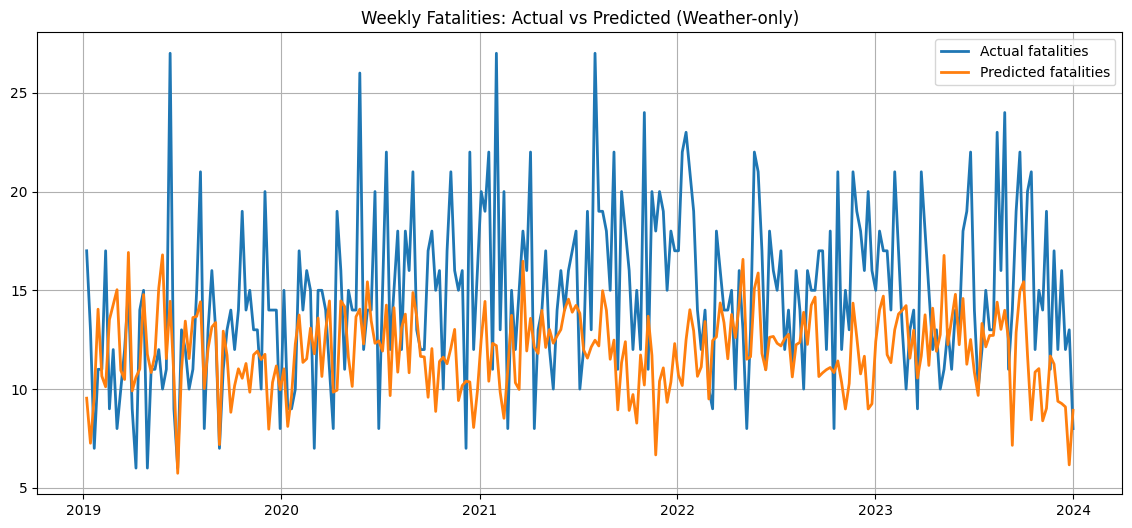

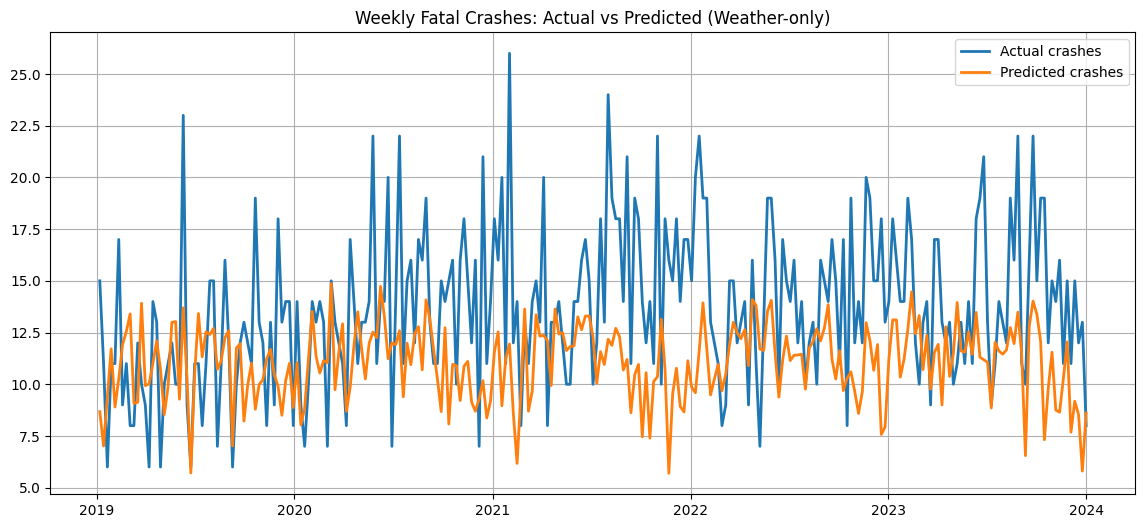


Random Week selected: Week 44, 2020


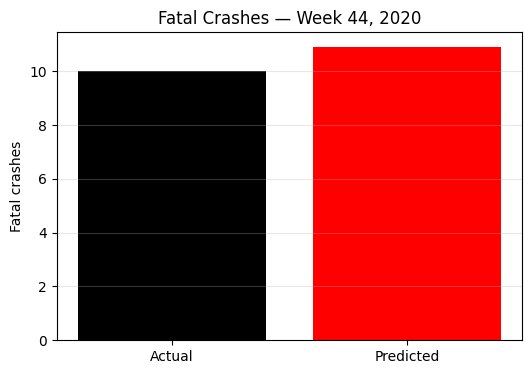

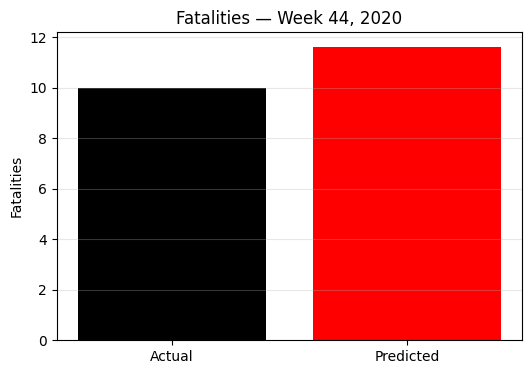

In [30]:
data_path = project_root / "data/dallas_accidents" / "dallas_weather_accidents_2010_2023.csv"

df = pd.read_csv(data_path, parse_dates=["date"])

weather_cols = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "wind_speed_10m_mean",
    "wind_speed_10m_max",
    "cloudcover_mean",
    "shortwave_radiation_sum",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "relative_humidity_2m_mean",
]

daily = (
    df.groupby("date")
      .agg(
          fatalities=("FATALS", "sum"),
          crashes=("ST_CASE", "nunique"),
          drunk_drivers=("DRUNK_DR", "sum"),
          drunk_crashes=("DRUNK_DR", lambda x: (x > 0).sum()),
          **{col: (col, "mean") for col in weather_cols}
      )
      .reset_index()
)

daily["year"] = daily["date"].dt.year

weekly = (
    daily.set_index("date")
         .resample("W-MON")
         .agg({
             "fatalities": "sum",
             "crashes": "sum",
             "drunk_drivers": "sum",
             "drunk_crashes": "sum",
             "temperature_2m_mean": "mean",
             "temperature_2m_max": "max",
             "temperature_2m_min": "min",
             "wind_speed_10m_mean": "mean",
             "wind_speed_10m_max": "max",
             "cloudcover_mean": "mean",
             "shortwave_radiation_sum": "sum",
             "precipitation_sum": "sum",
             "rain_sum": "sum",
             "snowfall_sum": "sum",
             "relative_humidity_2m_mean": "mean",
         })
         .reset_index()
)

weekly["year"] = weekly["date"].dt.year
weekly["week"] = weekly["date"].dt.isocalendar().week.astype(int)

train = weekly[weekly["date"].dt.year <= 2018]
test  = weekly[weekly["date"].dt.year >= 2019]

weather_features_only = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "wind_speed_10m_mean",
    "wind_speed_10m_max",
    "cloudcover_mean",
    "shortwave_radiation_sum",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "relative_humidity_2m_mean",
]

target_fatal = "fatalities"

X_train_fatal = train[weather_features_only]
y_train_fatal = train[target_fatal]

X_test_fatal  = test[weather_features_only]
y_test_fatal  = test[target_fatal]

model_fatal = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model_fatal.fit(X_train_fatal, y_train_fatal)

pred_fatal = model_fatal.predict(X_test_fatal)

rmse_fatal = np.sqrt(mean_squared_error(y_test_fatal, pred_fatal))
mae_fatal = mean_absolute_error(y_test_fatal, pred_fatal)

print("Model based just on the weather (number of fatalities)")
print("RMSE:", rmse_fatal)
print("MAE:", mae_fatal)

target_crashes = "crashes"

X_train_crash = train[weather_features_only]
y_train_crash = train[target_crashes]

X_test_crash  = test[weather_features_only]
y_test_crash  = test[target_crashes]

model_crash = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model_crash.fit(X_train_crash, y_train_crash)

pred_crash = model_crash.predict(X_test_crash)

rmse_crash = np.sqrt(mean_squared_error(y_test_crash, pred_crash))
mae_crash = mean_absolute_error(y_test_crash, pred_crash)

print("Model based just on the weather (number of fatal crashes)")
print("RMSE:", rmse_crash)
print("MAE:", mae_crash)

plt.figure(figsize=(14,6))
plt.plot(test["date"], y_test_fatal, label="Actual fatalities", linewidth=2)
plt.plot(test["date"], pred_fatal, label="Predicted fatalities", linewidth=2)
plt.legend()
plt.title("Weekly Fatalities: Actual vs Predicted (Weather-only)")
plt.grid()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(test["date"], y_test_crash, label="Actual crashes", linewidth=2)
plt.plot(test["date"], pred_crash, label="Predicted crashes", linewidth=2)
plt.legend()
plt.title("Weekly Fatal Crashes: Actual vs Predicted (Weather-only)")
plt.grid()
plt.show()

idx = random.choice(test.index)

chosen_year = int(test.loc[idx, "year"])
chosen_week = int(test.loc[idx, "week"])
chosen_date = test.loc[idx, "date"]

print(f"\nRandom Week selected: Week {chosen_week}, {chosen_year}")

X_row = test.loc[idx:idx, weather_features_only]

pred_week_crashes = float(model_crash.predict(X_row)[0])
pred_week_fatalities = float(model_fatal.predict(X_row)[0])

actual_week_crashes = float(test.loc[idx, "crashes"])
actual_week_fatalities = float(test.loc[idx, "fatalities"])

plt.figure(figsize=(6,4))
plt.bar(["Actual", "Predicted"],
        [actual_week_crashes, pred_week_crashes],
        color=["black", "red"])
plt.title(f"Fatal Crashes — Week {chosen_week}, {chosen_year}")
plt.ylabel("Fatal crashes")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["Actual", "Predicted"],
        [actual_week_fatalities, pred_week_fatalities],
        color=["black", "red"])
plt.title(f"Fatalities — Week {chosen_week}, {chosen_year}")
plt.ylabel("Fatalities")
plt.grid(axis="y", alpha=0.3)
plt.show()

#### **Conclusion**

**Can detailed historical weather data alone predict weekly traffic fatalities in a major U.S. city?**
No.

The weather-only model shows that weekly weather conditions by themselves have very limited ability to predict fatal crashes or fatalities in the Dallas area. The predicted values stay near the overall average and fail to track the sharp spikes and drops seen in the real data. This indicates that short-term fatal crash patterns are driven far more by traffic volume, behavior, and other non-weather factors. Weather contributes some information, but on its own it is not a strong predictor of weekly fatal crashes or fatalities.


## 4. Predictive modeling for Los Angeles clusters


### 4.1. Loading the accident data

Traffic accident records from the Fatality Analysis Reporting System (FARS) for the years **2015-2023** are loaded by reading annual accident.csv files, which are then concatenated into a single dataset.

To focus the analysis on **Los Angeles**, the dataset is first restricted
to **California (STATE = 6)** and then filtered using a geographic bounding
box covering the Los Angeles metropolitan area. When available, the most
frequent city code within this region is inferred and used to further
refine the subset. The resulting dataset represents traffic accidents
occurring in Los Angeles between 2015 and 2023 and serves as the foundation
for subsequent analysis and modeling.


In [52]:
def load_fars_accident_2015_2023(data_folder: Path):
    all_data = []

    cols_needed = [
        "ST_CASE", "STATE", "CITY",
        "LATITUDE", "LONGITUD",
        "YEAR", "MONTH", "DAY", "HOUR",
        "WEATHER", "LGT_COND",
        "FATALS"
    ]

    for year in range(2015, 2024):
        acc_file = data_folder / str(year) / "accident.csv"
        if not acc_file.exists():
            print(f"Missing: {acc_file}")
            continue

        try:
            df = pd.read_csv(acc_file, low_memory=False, encoding="utf-8")
        except UnicodeDecodeError:
            df = pd.read_csv(acc_file, low_memory=False, encoding="latin1")

        cols_to_use = [c for c in cols_needed if c in df.columns]
        df = df[cols_to_use].copy()

        if "YEAR" not in df.columns:
            df["YEAR"] = year
        else:
            df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").fillna(year).astype(int)

        all_data.append(df)

    if not all_data:
        raise FileNotFoundError("No accident.csv files found for years 2015-2023")

    full_data = pd.concat(all_data, ignore_index=True)

    for c in ["LATITUDE", "LONGITUD", "HOUR", "MONTH", "DAY", "STATE", "CITY"]:
        if c in full_data.columns:
            full_data[c] = pd.to_numeric(full_data[c], errors="coerce")

    full_data = full_data[
        (full_data["HOUR"].notna()) &
        (full_data["HOUR"] >= 0) &
        (full_data["HOUR"] <= 23)
    ].copy()

    return full_data

full_data = load_fars_accident_2015_2023(data_folder)
full_data.shape

(319634, 12)

In [53]:
def filter_los_angeles_accident(full_data: pd.DataFrame):
    ca = full_data[full_data["STATE"] == 6].copy()
    lat_min, lat_max = 33.70, 34.40
    lon_min, lon_max = -118.70, -118.10

    ca = ca.dropna(subset=["LATITUDE", "LONGITUD"])
    in_bbox = ca[
        (ca["LATITUDE"].between(lat_min, lat_max)) &
        (ca["LONGITUD"].between(lon_min, lon_max))
    ].copy()

    if "CITY" in in_bbox.columns and in_bbox["CITY"].notna().any():
        la_city_code = int(in_bbox["CITY"].mode().iloc[0])
        print(f"Inferred LA CITY code (from bbox): {la_city_code}")
        la = ca[ca["CITY"] == la_city_code].copy()
    else:
        la = in_bbox.copy()

    return la

la_data = filter_los_angeles_accident(full_data)
la_data.shape

Inferred LA CITY code (from bbox): 1980


(2590, 12)

### 4.2. Mappings and helper functions


This section defines supporting mappings and utility functions used throughout the Los Angeles predictive modeling pipeline.

Key elements include:

- **Weather and light condition mapping**:
  A dictionary (WEATHER_MAP) that converts numeric weather codes from the accident dataset into human-readable weather descriptions (e.g., Clear, Rain, Snow, Fog). This improves interpretability during analysis and visualization. The same thing was done with a dictionary (LGT_COND_MAP).

- **cluster_year_hdbscan function** that: filters Los Angeles accident data for a specific year, applies the HDBSCAN clustering algorithm to latitude and longitude coordinates, identifies the top spatial clusters based on accident density


In [18]:
WEATHER_MAP = {
    1: "Clear",
    2: "Rain",
    3: "Sleet / Hail",
    4: "Snow",
    5: "Fog / Smog / Smoke",
    6: "Severe Crosswinds",
    7: "Blowing Sand, Soil, Dirt",
    8: "Other",
    10: "Cloudy",
    11: "Blowing Snow",
    12: "Freezing Rain or Drizzle",
    98: "Not Reported",
    99: "Unknown"
}

LGT_COND_MAP = {
    1: "Daylight",
    2: "Dark - Not Lighted",
    3: "Dark - Lighted",
    4: "Dawn",
    5: "Dusk",
    6: "Dark - Unknown Lighting",
    7: "Other",
    8: "Not reported",
    9: "Unknown"
}

In [19]:
def cluster_year_hdbscan(la_data: pd.DataFrame, year: int, top_x: int = 5,
                         min_cluster_size: int = 20, min_samples: int = 8):

    df = la_data[la_data["YEAR"] == year].copy()
    df = df.dropna(subset=["LATITUDE", "LONGITUD"])

    coords = df[["LATITUDE", "LONGITUD"]].values
    coords_rad = np.radians(coords)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="haversine",
        cluster_selection_method="leaf"
    )

    df["cluster"] = clusterer.fit_predict(coords_rad)

    stats = (
        df[df["cluster"] != -1]
        .groupby("cluster")
        .agg(
            fatal_crashes=("ST_CASE", "count"),
            mean_lat=("LATITUDE", "mean"),
            mean_lon=("LONGITUD", "mean")
        )
        .sort_values("fatal_crashes", ascending=False)
    )

    top = stats.head(top_x)

    print(f"LA {year}: total crashes={len(df)}, clusters={stats.shape[0]}, noise={(df['cluster']==-1).sum()}")
    return df, top, stats

In [20]:
def compute_cluster_centroids(df):
    return (
        df[df["cluster"] != -1]
        .groupby("cluster")
        .agg(
            mean_lat=("LATITUDE", "mean"),
            mean_lon=("LONGITUD", "mean"),
            fatal_count=("ST_CASE", "count"),
        )
        .reset_index()
    )

### 4.3. Creating cluster maps


#### 4.3.1. Creating a cluster map for each year 2015-2023


This section builds an interactive Folium map to visualize spatial clusters of fatal traffic crashes in Los Angeles from 2015 to 2023. For each year, accident locations are clustered using the HDBSCAN algorithm and added as a separate selectable map layer. Individual crashes are shown as circle markers, with colors indicating their cluster assignment and a neutral color used for noise points.

Popups attached to each marker display key contextual information, including the year, cluster identifier, hour of occurrence, weather condition, and light condition, with coded variables mapped to readable labels. In addition, the geographic centroid of each cluster is marked on the map and annotated with the cluster ID and the total number of fatal crashes in that cluster.

A grouped layer control allows users to toggle between years, enabling visual comparison of spatial patterns over time. The resulting interactive map is saved as an HTML file for external exploration.


In [22]:
def safe_int(x):
    return int(x) if pd.notna(x) else "NA"

def map_code(x, mapping):
    if pd.isna(x):
        return "NA"
    x = int(x)
    return mapping.get(x, f"Unknown ({x})")

def make_color_map_for_year(cluster_labels):
    unique_clusters = sorted(c for c in cluster_labels if c != -1)

    base_colors = list(matplotlib.colormaps["tab10"].colors)

    color_map = {}

    for i, c in enumerate(unique_clusters):
        rgb = base_colors[i % len(base_colors)]
        color_map[c] = "#{:02x}{:02x}{:02x}".format(
            int(rgb[0] * 255),
            int(rgb[1] * 255),
            int(rgb[2] * 255),
        )

    color_map[-1] = "#e0e0e0"

    return color_map

m = folium.Map(
    location=[34.05, -118.25],
    zoom_start=10,
    tiles="cartodbpositron"
)

year_layers = {}

for year in range(2015, 2024):
    df_year, _, _ = cluster_year_hdbscan(
        la_data,
        year=year,
        min_cluster_size=8,
        min_samples=4
    )

    fg = folium.FeatureGroup(
        name=str(year),
        show=(year == 2015)
    )

    color_map = make_color_map_for_year(df_year["cluster"].unique())

    for _, row in df_year.iterrows():
        weather_label = map_code(row.get("WEATHER"), WEATHER_MAP)
        light_label = map_code(row.get("LGT_COND"), LGT_COND_MAP)

        popup_html = f"""
        <b>Year:</b> {int(row['YEAR'])}<br>
        <b>Cluster:</b> {safe_int(row['cluster'])}<br>
        <b>Hour:</b> {safe_int(row.get('HOUR'))}<br>
        <b>Weather:</b> {weather_label}<br>
        <b>Light condition:</b> {light_label}
        """

        folium.CircleMarker(
            location=[row["LATITUDE"], row["LONGITUD"]],
            radius=3,
            color=color_map[row["cluster"]],
            fill=True,
            fill_opacity=0.6,
            popup=popup_html
        ).add_to(fg)

    cluster_centers = compute_cluster_centroids(df_year)

    for _, row_c in cluster_centers.iterrows():
        popup_html = f"""
        <b>Cluster:</b> {safe_int(row_c['cluster'])}<br>
        <b>Fatal crashes:</b> {safe_int(row_c['fatal_count'])}<br>
        """

        folium.Marker(
            location=[row_c["mean_lat"], row_c["mean_lon"]],
            popup=popup_html,
            icon=folium.Icon(
                color="red",
                icon="info-sign",
                prefix="glyphicon"
            ),
        ).add_to(fg)

    fg.add_to(m)
    year_layers[str(year)] = fg

GroupedLayerControl(
    groups={
        "Year": list(year_layers.values())
    },
    exclusive_groups=True,
    collapsed=False
).add_to(m)

maps_dir = Path("../data/maps")
maps_dir.mkdir(parents=True, exist_ok=True)

m.save(maps_dir / "la_fatal_clusters_by_year.html")

LA 2015: total crashes=230, clusters=7, noise=130
LA 2016: total crashes=313, clusters=11, noise=146
LA 2017: total crashes=275, clusters=10, noise=161
LA 2018: total crashes=270, clusters=12, noise=144
LA 2019: total crashes=263, clusters=8, noise=64
LA 2020: total crashes=273, clusters=10, noise=159
LA 2021: total crashes=322, clusters=13, noise=149
LA 2022: total crashes=338, clusters=10, noise=174
LA 2023: total crashes=306, clusters=10, noise=153


#### 4.3.2. Creating a cluster map for 2023 with all accident data


This section creates an interactive Folium map focused on fatal traffic crash clusters in Los Angeles for the year 2023. Accident locations for 2023 are clustered using the HDBSCAN algorithm, while fatal crashes from **all other years** are included as background context.

Crashes belonging to identified clusters are displayed with larger, color-coded markers, while unclustered crashes and crashes from other years are shown as smaller gray markers. Interactive popups provide contextual information such as the year, hour of occurrence, weather condition, and light condition, with cluster identifiers shown when applicable.

For each 2023 cluster, the geographic centroid is computed and marked on the map. A 2-kilometer radius circle is drawn around each centroid, and the total number of fatal crashes from all years within this radius is calculated and displayed. This allows comparison between cluster locations and broader historical crash density.


In [24]:
def safe_int(x):
    return int(x) if pd.notna(x) else "NA"

def map_code(x, mapping):
    if pd.isna(x):
        return "NA"
    x = int(x)
    return mapping.get(x, f"Unknown ({x})")

def make_color_map_for_year(cluster_labels):
    unique_clusters = sorted(c for c in cluster_labels if c != -1)

    base_colors = list(matplotlib.colormaps["tab10"].colors)

    color_map = {}

    for i, c in enumerate(unique_clusters):
        rgb = base_colors[i % len(base_colors)]
        color_map[c] = "#{:02x}{:02x}{:02x}".format(
            int(rgb[0] * 255),
            int(rgb[1] * 255),
            int(rgb[2] * 255),
        )

    color_map[-1] = "#e0e0e0"

    return color_map

m = folium.Map(
    location=[34.05, -118.25],
    zoom_start=10,
    tiles="cartodbpositron"
)

df_2023, _, _ = cluster_year_hdbscan(
    la_data,
    year=2023,
    min_cluster_size=8,
    min_samples=4
)

df_other_years = la_data[la_data["YEAR"] != 2023]

color_map = make_color_map_for_year(df_2023["cluster"].unique())

fg_other = folium.FeatureGroup(name="Other accidents")
fg_clusters = folium.FeatureGroup(name="Fatal crash clusters")

for _, row in df_2023.iterrows():
    weather_label = map_code(row.get("WEATHER"), WEATHER_MAP)
    light_label = map_code(row.get("LGT_COND"), LGT_COND_MAP)

    popup_html = f"""
    <b>Year:</b> {int(row['YEAR'])}<br>
    <b>Hour:</b> {safe_int(row.get('HOUR'))}<br>
    <b>Weather:</b> {weather_label}<br>
    <b>Light condition:</b> {light_label}
    """

    if row["cluster"] != -1:
        popup_html += f"<br><b>Cluster:</b> {safe_int(row['cluster'])}"

        folium.CircleMarker(
            location=[row["LATITUDE"], row["LONGITUD"]],
            radius=3,
            color=color_map[row["cluster"]],
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(fg_clusters)
    else:
        folium.CircleMarker(
            location=[row["LATITUDE"], row["LONGITUD"]],
            radius=1,
            color="#BEBEBE",
            fill=True,
            fill_opacity=0.4,
            popup=popup_html
        ).add_to(fg_other)

for _, row in df_other_years.iterrows():

    weather_label = map_code(row.get("WEATHER"), WEATHER_MAP)
    light_label = map_code(row.get("LGT_COND"), LGT_COND_MAP)

    popup_html = f"""
    <b>Year:</b> {safe_int(row.get('YEAR'))}<br>
    <b>Hour:</b> {safe_int(row.get('HOUR'))}<br>
    <b>Weather:</b> {weather_label}<br>
    <b>Light condition:</b> {light_label}
    """

    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUD"]],
        radius=1,
        color="#BEBEBE",
        fill=True,
        fill_opacity=0.4,
        popup=popup_html
    ).add_to(fg_other)

all_coords_rad = np.radians(
    la_data[["LATITUDE", "LONGITUD"]].values
)

EARTH_RADIUS_M = 6371000

cluster_centers = compute_cluster_centroids(df_2023)

for _, row_c in cluster_centers.iterrows():
    center_rad = np.radians([[row_c["mean_lat"], row_c["mean_lon"]]])

    distances_m = (
        haversine_distances(center_rad, all_coords_rad)[0]
        * EARTH_RADIUS_M
    )

    accidents_in_radius = int(np.sum(distances_m <= 2000))

    popup_html = f"""
    <b>Cluster:</b> {safe_int(row_c['cluster'])}<br>
    <b>All fatal crashes within 2 km:</b> {accidents_in_radius}
    """

    folium.Circle(
        location=[row_c["mean_lat"], row_c["mean_lon"]],
        radius=2000,
        color="#999999",
        weight=1.5,
        fill=False,
        interactive=False
    ).add_to(fg_clusters)

    folium.Marker(
        location=[row_c["mean_lat"], row_c["mean_lon"]],
        popup=popup_html,
        icon=folium.Icon(
            color="red",
            icon="info-sign",
            prefix="glyphicon"
        )
    ).add_to(fg_clusters)

fg_other.add_to(m)
fg_clusters.add_to(m)

maps_dir = Path("../data/maps")
maps_dir.mkdir(parents=True, exist_ok=True)
m.save(maps_dir / "la_fatal_clusters_2023.html")

LA 2023: total crashes=306, clusters=10, noise=153


### 4.4. Charts for the HTML


This section generates interactive bar charts to summarize the temporal and environmental characteristics of fatal traffic crashes in Los Angeles. Using Plotly, fatal crashes are aggregated by hour of the day, weather condition, and light condition.

Charts are first created for the full study period from 2015 to 2023, showing overall patterns across all years. The same set of charts is then generated separately for each individual year, allowing year-by-year comparison of crash distributions.

All charts are saved as standalone HTML files, making them suitable for inclusion in app.html


In [25]:
def make_charts(df, year_label):
    hour_counts = df.groupby("HOUR").size().reset_index(name="count")

    fig_hour = px.bar(
        hour_counts,
        x="HOUR",
        y="count",
        title=f"Fatal Crashes per Hour ({year_label})"
    )

    weather_counts = (
        df["WEATHER"]
        .map(WEATHER_MAP)
        .value_counts()
        .reset_index()
    )
    weather_counts.columns = ["Weather", "count"]

    fig_weather = px.bar(
        weather_counts,
        x="Weather",
        y="count",
        title=f"Fatal Crashes by Weather ({year_label})"
    )

    light_counts = (
        df["LGT_COND"]
        .map(LGT_COND_MAP)
        .value_counts()
        .reset_index()
    )
    light_counts.columns = ["Light Condition", "count"]

    fig_light = px.bar(
        light_counts,
        x="Light Condition",
        y="count",
        title=f"Fatal Crashes by Light Condition ({year_label})"
    )

    return fig_hour, fig_weather, fig_light

charts_dir = Path("../data/charts_for_html")
charts_dir.mkdir(parents=True, exist_ok=True)

figs = make_charts(la_data, "2015-2023")
write_html(figs[0], charts_dir / "hours_all.html")
write_html(figs[1], charts_dir / "weather_all.html")
write_html(figs[2], charts_dir / "light_all.html")

for year in range(2015, 2024):
    df_year = la_data[la_data["YEAR"] == year]
    figs = make_charts(df_year, str(year))

    write_html(figs[0], charts_dir / f"hours_{year}.html")
    write_html(figs[1], charts_dir / f"weather_{year}.html")
    write_html(figs[2], charts_dir / f"light_{year}.html")

### 4.5. Models


In this section, the prediction process works as follows. We use 2023 as the reference year since it is the most recent dataset available. First, accident data are grouped into clusters. For each cluster, we compute its geographical center. Around each center, we define a 2 km radius area, which represents the zone of interest. Using the historical patterns within these areas, the **Model 1 (Structural model)** and **Model 2 (Structural + past crashes model)** then predict the number of fatal accidents for a selected year. **Model 3 (Structural + weather model)** extends this framework by estimating the daily probability of a fatal accident within each cluster, incorporating road network characteristics together with local weather conditions to capture short-term environmental risk factors.

#### 4.5.1. Preparing the data


In [33]:
REFERENCE_YEAR = 2023

df_ref, _, _ = cluster_year_hdbscan(
    la_data,
    year=REFERENCE_YEAR,
    min_cluster_size=8,
    min_samples=4
)

df_ref = df_ref[df_ref["cluster"] != -1].copy()

cluster_centers = (
    df_ref
    .groupby("cluster")
    .agg(
        mean_lat=("LATITUDE", "mean"),
        mean_lon=("LONGITUD", "mean"),
    )
    .reset_index()
)

cluster_centers.head()

LA 2023: total crashes=306, clusters=10, noise=153


,cluster,mean_lat,mean_lon
0,0,33.779361,-118.276450
1,1,34.231042,-118.548091
2,2,34.161866,-118.377803
3,3,34.217290,-118.418889
4,4,34.269528,-118.433516


In [34]:
OSM_RADIUS_M = 2000

def osm_features_for_cluster(lat, lon, dist=OSM_RADIUS_M):
    try:
        G = ox.graph_from_point(
            (lat, lon),
            dist=dist,
            network_type="drive",
            simplify=True
        )

        edges = ox.graph_to_gdfs(G, nodes=False)

        # number of road segments in the area
        road_density = len(edges)

        # true intersections: nodes with degree >= 3
        intersection_density = sum(
            1 for _, deg in G.degree() if deg >= 3
        )

        # fraction of major roads
        primary_frac = (
            edges["highway"]
            .apply(
                lambda x: (
                    any(h in ["primary", "trunk", "motorway"] for h in x)
                    if isinstance(x, list)
                    else x in ["primary", "trunk", "motorway"]
                )
            )
            .mean()
        )

        return pd.Series({
            "road_density": road_density,
            "intersection_density": intersection_density,
            "primary_road_frac": primary_frac
        })

    except Exception:
        return pd.Series({
            "road_density": np.nan,
            "intersection_density": np.nan,
            "primary_road_frac": np.nan
        })

osm_features = cluster_centers.apply(
    lambda r: osm_features_for_cluster(
        r["mean_lat"], r["mean_lon"]
    ),
    axis=1
)

cluster_centers = pd.concat(
    [cluster_centers, osm_features], axis=1
)

cluster_centers

,cluster,mean_lat,mean_lon,road_density,intersection_density,primary_road_frac
0,0,33.779361,-118.276450,1672.0,495.0,0.069976
1,1,34.231042,-118.548091,2056.0,592.0,0.074903
2,2,34.161866,-118.377803,2807.0,856.0,0.097969
3,3,34.217290,-118.418889,2143.0,643.0,0.079795
4,4,34.269528,-118.433516,2558.0,766.0,0.108288
5,5,34.034224,-118.227730,2689.0,885.0,0.140945
6,6,34.035258,-118.325848,2941.0,917.0,0.084665
7,7,34.064667,-118.290669,3295.0,998.0,0.125341
8,8,33.937020,-118.278379,2741.0,877.0,0.093032
9,9,33.971813,-118.301665,3428.0,1054.0,0.124854


In [35]:
EARTH_RADIUS_M = 6371000
ASSIGN_RADIUS_M = 2000

coords_ref = np.radians(cluster_centers[["mean_lat", "mean_lon"]].values)
tree = BallTree(coords_ref, metric="haversine")

def assign_to_reference_clusters_radius(df, tree, cluster_centers, radius_m=ASSIGN_RADIUS_M):
    df = df.dropna(subset=["LATITUDE", "LONGITUD"]).copy()
    coords = np.radians(df[["LATITUDE", "LONGITUD"]].values)

    dist_rad, idx = tree.query(coords, k=1)
    dist_m = dist_rad.flatten() * EARTH_RADIUS_M
    idx = idx.flatten()

    df["ref_cluster"] = cluster_centers.iloc[idx]["cluster"].values
    df["dist_to_cluster_m"] = dist_m

    # cutoff
    df.loc[df["dist_to_cluster_m"] > radius_m, "ref_cluster"] = -1
    return df

la_data_assigned = assign_to_reference_clusters_radius(la_data, tree, cluster_centers, radius_m=ASSIGN_RADIUS_M)
la_data_in = la_data_assigned[la_data_assigned["ref_cluster"] != -1].copy()

print("Assigned share:", (la_data_assigned["ref_cluster"] != -1).mean())
la_data_in

Assigned share: 0.2247104247104247


,ST_CASE,STATE,CITY,LATITUDE,LONGITUD,YEAR,MONTH,DAY,HOUR,WEATHER,LGT_COND,FATALS,ref_cluster,dist_to_cluster_m
2155,60010,6,1980,33.989136,-118.303900,2015,1,4,2,1,3,1,9,1937.250219
2209,60064,6,1980,33.982319,-118.308989,2015,1,15,7,1,1,1,9,1349.429696
2365,60220,6,1980,33.968158,-118.309031,2015,2,10,6,1,4,1,9,791.521086
2384,60239,6,1980,34.027381,-118.210394,2015,2,15,9,1,1,1,5,1769.461668
2393,60248,6,1980,33.790978,-118.266539,2015,1,29,15,1,1,2,0,1583.560112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290283,63252,6,1980,33.949222,-118.273850,2023,6,20,19,1,3,1,8,1419.642082
290285,63254,6,1980,34.257686,-118.435414,2023,9,30,3,10,3,1,4,1328.236248
290313,63282,6,1980,33.937431,-118.278133,2023,2,10,23,1,3,1,8,50.923595
290446,63416,6,1980,33.974592,-118.287139,2023,11,19,6,1,3,1,9,1374.676461


In [36]:
cluster_year = (
    la_data_in
    .groupby(["ref_cluster", "YEAR"])
    .agg(fatal_count=("ST_CASE", "count"))
    .reset_index()
    .rename(columns={"ref_cluster": "cluster"})
)

cluster_year = cluster_year.sort_values(["cluster", "YEAR"]).reset_index(drop=True)
cluster_year

,cluster,YEAR,fatal_count
0,0,2015,3
1,0,2016,3
2,0,2017,5
3,0,2018,1
4,0,2019,4
...,...,...,...
84,9,2019,8
85,9,2020,9
86,9,2021,7
87,9,2022,19


In [37]:
cluster_year["fatal_prev_1"] = cluster_year.groupby("cluster")["fatal_count"].shift(1)
cluster_year["fatal_prev_2"] = cluster_year.groupby("cluster")["fatal_count"].shift(2)

cluster_year_model = cluster_year.dropna(subset=["fatal_prev_1", "fatal_prev_2"]).reset_index(drop=True)

cluster_year_model

,cluster,YEAR,fatal_count,fatal_prev_1,fatal_prev_2
0,0,2017,5,3.0,3.0
1,0,2018,1,5.0,3.0
2,0,2019,4,1.0,5.0
3,0,2020,4,4.0,1.0
4,0,2021,12,4.0,4.0
...,...,...,...,...,...
64,9,2019,8,17.0,11.0
65,9,2020,9,8.0,17.0
66,9,2021,7,9.0,8.0
67,9,2022,19,7.0,9.0


In [38]:
model_df = cluster_year_model.merge(
    cluster_centers[["cluster", "mean_lat", "mean_lon", "road_density", "intersection_density", "primary_road_frac"]],
    on="cluster",
    how="left"
)

model_df

,cluster,YEAR,fatal_count,fatal_prev_1,fatal_prev_2,mean_lat,mean_lon,road_density,intersection_density,primary_road_frac
0,0,2017,5,3.0,3.0,33.779361,-118.276450,1672.0,495.0,0.069976
1,0,2018,1,5.0,3.0,33.779361,-118.276450,1672.0,495.0,0.069976
2,0,2019,4,1.0,5.0,33.779361,-118.276450,1672.0,495.0,0.069976
3,0,2020,4,4.0,1.0,33.779361,-118.276450,1672.0,495.0,0.069976
4,0,2021,12,4.0,4.0,33.779361,-118.276450,1672.0,495.0,0.069976
...,...,...,...,...,...,...,...,...,...,...
64,9,2019,8,17.0,11.0,33.971813,-118.301665,3428.0,1054.0,0.124854
65,9,2020,9,8.0,17.0,33.971813,-118.301665,3428.0,1054.0,0.124854
66,9,2021,7,9.0,8.0,33.971813,-118.301665,3428.0,1054.0,0.124854
67,9,2022,19,7.0,9.0,33.971813,-118.301665,3428.0,1054.0,0.124854


#### 4.5.2. Training and evaluation of the models


Due to the limited size of the dataset, a forward-chaining evaluation strategy
was adopted. Data from 2017-2021 was used for model training because that is the data that had previous 2 years of data that the Model 2 needs, while the data from 2022-2023 was used for testing.


##### **Model 1 (Structural model)**


This model uses Poisson regression to predict the number of fatal crashes based on road network characteristics. The input features include road density, intersection density, and the fraction of primary roads. Features are standardized before training to ensure stable model fitting.

The model is trained on the training dataset (2017-2021) and evaluated on (2022-2023) test set. Its performance is compared against a simple baseline that uses the exact/known previous year’s fatal crash count as the prediction for the next year. Model accuracy is assessed using mean absolute error (MAE).

Model coefficients are extracted and analyzed to evaluate the relative influence of each feature on predicted fatal crash counts.


In [43]:
train = model_df[model_df["YEAR"] <= 2021].copy()
test  = model_df[model_df["YEAR"] >= 2022].copy()

print(train["YEAR"].min(), "-", train["YEAR"].max(), "train rows:", len(train))
print(test["YEAR"].min(), "-", test["YEAR"].max(), "test rows:", len(test))

2017 - 2021 train rows: 49
2022 - 2023 test rows: 20


In [44]:
features = [
    "road_density",
    "intersection_density",
    "primary_road_frac",
]

X_train = train[features]
y_train = train["fatal_count"]
X_test  = test[features]
y_test  = test["fatal_count"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

poisson = PoissonRegressor(
    alpha=0.001,     
    max_iter=5000
)

poisson.fit(X_train_scaled, y_train)

test = test.copy()

test["pred_poisson"] = poisson.predict(X_test_scaled)
test["pred_baseline"] = test["fatal_prev_1"]

mae_poisson = mean_absolute_error(y_test, test["pred_poisson"])
mae_baseline = mean_absolute_error(y_test, test["pred_baseline"])

print("MAE baseline:", mae_baseline)
print("MAE poisson :", mae_poisson)

coef = pd.Series(
    poisson.coef_,
    index=features
).sort_values(key=np.abs, ascending=False)

coef

MAE baseline: 3.9
MAE poisson : 3.178208465388581


intersection_density    1.251956
road_density           -0.827758
primary_road_frac      -0.109542
dtype: float64

**Model performance**

The Poisson regression model achieved a mean absolute error (MAE) of 3.18 on the 2022-2023 test period, outperforming a persistence-based baseline that assumes fatal crash counts remain unchanged from the previous year (MAE = 3.90). This represents an improvement of approximately 18%, indicating that the model captures meaningful spatial structure in roadway characteristics.

**Feature interpretation**

Intersection density emerged as the most influential predictor, exhibiting a strong positive association with fatal crash frequency. This finding highlights the role of complex traffic environments, where a higher number of conflict points increases the likelihood of severe crashes. In contrast, road density showed a negative association with fatal crash counts, likely reflecting lower average travel speeds and traffic-calming effects in denser urban street networks. The fraction of primary roads exhibited a relatively weak association with fatal crash counts, indicating that network complexity and intersection density are more important determinants of crash risk than road classification alone. Overall, the results indicate that spatial road characteristics provide a stable structural baseline upon which temporal or environmental factors may further act.


**Saving the results**


In [45]:
evaluation = {}

for year in [2022, 2023]:
    df_year = test[test["YEAR"] == year]

    evaluation[str(year)] = [
        {
            "cluster_id": int(row["cluster"]),
            "observed_crashes": int(row["fatal_count"]),
            "predicted_crashes": round(float(row["pred_poisson"]), 2),
            "absolute_error": round(
                abs(row["fatal_count"] - row["pred_poisson"]), 2
            )
        }
        for _, row in df_year.iterrows()
    ]

performance_summary = {
    "mae_baseline": round(mae_baseline, 3),
    "mae_poisson": round(mae_poisson, 3),
    "improvement_percent": round(
        (mae_baseline - mae_poisson) / mae_baseline * 100, 1
    )
}

spatial_2023 = model_df[model_df["YEAR"] == 2023][
    ["cluster", "road_density", "intersection_density", "primary_road_frac"]
]

fatal_2023 = model_df[model_df["YEAR"] == 2023][
    ["cluster", "fatal_count"]
].rename(columns={"fatal_count": "fatal_prev_1"})

fatal_2022 = model_df[model_df["YEAR"] == 2022][
    ["cluster", "fatal_count"]
].rename(columns={"fatal_count": "fatal_prev_2"})

X_2024 = (
    spatial_2023
    .merge(fatal_2023, on="cluster")
    .merge(fatal_2022, on="cluster")
    .sort_values("cluster")
)

X_2024_scaled = scaler.transform(X_2024[features])
pred_2024 = poisson.predict(X_2024_scaled)

def fatal_risk(pred):
    if pred < 5:
        return 1  
    elif pred < 8:
        return 2   
    else:
        return 3

risk_label = {
    1: "Low",
    2: "Medium",
    3: "High"
}

prediction_2024 = [
    {
        "cluster_id": int(c),
        "predicted_crashes": round(float(p), 2),
        "fatal_risk": fatal_risk(p),
        "fatal_risk_label": risk_label[fatal_risk(p)]
    }
    for c, p in zip(X_2024["cluster"], pred_2024)
]

dashboard_data = {
    "performance_summary": performance_summary,
    "evaluation_2022": evaluation["2022"],
    "evaluation_2023": evaluation["2023"],
    "prediction_2024": prediction_2024
}

output_dir = Path("../data/predictions")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "model1_results.json"

with open(output_path, "w") as f:
    json.dump(dashboard_data, f, indent=2)

print(f"Saved model results to {output_path}")

Saved model results to ..\data\predictions\model1_results.json


##### **Model 2 (Structural + past crashes model)**


This model extends the Poisson regression approach by incorporating temporal information from previous years. In addition to road network characteristics, the model includes fatal crash counts from the previous one and two years as predictors.

The model is trained on the training dataset (2017-2021) and evaluated on (2022-2023) test set. Its performance is compared against a simple baseline that uses the exact/known previous year’s fatal crash count as the prediction for the next year. Model accuracy is assessed using mean absolute error (MAE).

Estimated coefficients are examined to assess the relative contribution of temporal and spatial features to fatal crash predictions.


In [49]:
train = model_df[model_df["YEAR"] <= 2021].copy()
test  = model_df[model_df["YEAR"] >= 2022].copy()

print(train["YEAR"].min(), "-", train["YEAR"].max(), "train rows:", len(train))
print(test["YEAR"].min(), "-", test["YEAR"].max(), "test rows:", len(test))

2017 - 2021 train rows: 49
2022 - 2023 test rows: 20


In [50]:
features = [
    "fatal_prev_1",
    "fatal_prev_2",
    "road_density",
    "intersection_density",
    "primary_road_frac",
]

X_train = train[features]
y_train = train["fatal_count"]
X_test  = test[features]
y_test  = test["fatal_count"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

poisson = PoissonRegressor(
    alpha=0.001,     
    max_iter=5000
)

poisson.fit(X_train_scaled, y_train)

test = test.copy()

test["pred_poisson"] = poisson.predict(X_test_scaled)
test["pred_baseline"] = test["fatal_prev_1"]

mae_poisson = mean_absolute_error(y_test, test["pred_poisson"])
mae_baseline = mean_absolute_error(y_test, test["pred_baseline"])

print("MAE baseline:", mae_baseline)
print("MAE poisson :", mae_poisson)

coef = pd.Series(
    poisson.coef_,
    index=features
).sort_values(key=np.abs, ascending=False)

coef

MAE baseline: 3.9
MAE poisson : 2.89753698073963


intersection_density    0.850202
road_density           -0.614041
fatal_prev_1            0.151881
primary_road_frac      -0.112393
fatal_prev_2            0.109422
dtype: float64

**Model performance**

When lagged fatal crash counts were added to the Poisson regression model, predictive performance improved further. The extended model achieved a mean absolute error (MAE) of 2.90 on the 2022-2023 test period, compared to MAE = 3.90 for the persistence-based baseline. Relative to the structural-only model, this represents a modest but consistent improvement, indicating that historical crash information provides additional predictive value beyond static road network characteristics. Overall, the results suggest that spatial roadway features define the baseline level of risk, while recent crash history refines short-term predictions of cluster-level fatal crash counts.

**Feature interpretation**

Consistent with the structural-only model, intersection density remained the dominant predictor of fatal crash frequency, exhibiting the largest positive association. Road density again showed a negative relationship, reinforcing the interpretation that denser urban street networks are associated with lower fatal crash counts, likely due to reduced travel speeds. Lagged fatal crash counts from the previous one and two years contributed positively to the model but with substantially smaller coefficients than the primary structural variables. This indicates that while past crash occurrence captures some temporal persistence, spatial road network characteristics remain the primary drivers of fatal crash risk across clusters.


**Saving the results**


In [51]:
evaluation = {}

for year in [2022, 2023]:
    df_year = test[test["YEAR"] == year]

    evaluation[str(year)] = [
        {
            "cluster_id": int(row["cluster"]),
            "observed_crashes": int(row["fatal_count"]),
            "predicted_crashes": round(float(row["pred_poisson"]), 2),
            "absolute_error": round(
                abs(row["fatal_count"] - row["pred_poisson"]), 2
            )
        }
        for _, row in df_year.iterrows()
    ]

performance_summary = {
    "mae_baseline": round(mae_baseline, 3),
    "mae_poisson": round(mae_poisson, 3),
    "improvement_percent": round(
        (mae_baseline - mae_poisson) / mae_baseline * 100, 1
    )
}

spatial_2023 = model_df[model_df["YEAR"] == 2023][
    ["cluster", "road_density", "intersection_density", "primary_road_frac"]
]

fatal_2023 = model_df[model_df["YEAR"] == 2023][
    ["cluster", "fatal_count"]
].rename(columns={"fatal_count": "fatal_prev_1"})

fatal_2022 = model_df[model_df["YEAR"] == 2022][
    ["cluster", "fatal_count"]
].rename(columns={"fatal_count": "fatal_prev_2"})

X_2024 = (
    spatial_2023
    .merge(fatal_2023, on="cluster")
    .merge(fatal_2022, on="cluster")
    .sort_values("cluster")
)

X_2024_scaled = scaler.transform(X_2024[features])
pred_2024 = poisson.predict(X_2024_scaled)

def fatal_risk(pred):
    if pred < 5:
        return 1  
    elif pred < 8:
        return 2   
    else:
        return 3

risk_label = {
    1: "Low",
    2: "Medium",
    3: "High"
}

prediction_2024 = [
    {
        "cluster_id": int(c),
        "predicted_crashes": round(float(p), 2),
        "fatal_risk": fatal_risk(p),
        "fatal_risk_label": risk_label[fatal_risk(p)]
    }
    for c, p in zip(X_2024["cluster"], pred_2024)
]

dashboard_data = {
    "performance_summary": performance_summary,
    "evaluation_2022": evaluation["2022"],
    "evaluation_2023": evaluation["2023"],
    "prediction_2024": prediction_2024
}

output_dir = Path("../data/predictions")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "model2_results.json"

with open(output_path, "w") as f:
    json.dump(dashboard_data, f, indent=2)

print(f"Saved model results to {output_path}")

Saved model results to ..\data\predictions\model2_results.json


##### **Model 3 (Structural + weather model)**


This model focuses on predicting the **daily probability** of a fatal accident within each cluster by combining accident data with road network characteristics, and weather conditions. Accident records are aggregated at the cluster-day level, ensuring a continuous daily time series even when no fatal events occur. Each cluster is enriched with static infrastructure features and dynamic weather variables obtained from the Open-Meteo API. A logistic regression model is then trained to estimate the likelihood of at least one fatal accident occurring on a given day, allowing us to assess how environmental and infrastructural factors influence fatal crash risk over time.


In [57]:
la_data_in["date"] = pd.to_datetime(
    la_data_in[["YEAR", "MONTH", "DAY"]]
)

cluster_day = (
    la_data_in
    .groupby(["ref_cluster", "date"], as_index=False)
    .agg(
        fatalities=("FATALS", "sum")
    )
)

cluster_day["fatal_event"] = (cluster_day["fatalities"] > 0).astype(int)

all_dates = pd.date_range(
    start=cluster_day["date"].min(),
    end=cluster_day["date"].max(),
    freq="D"
)

clusters = cluster_day["ref_cluster"].unique()

full_index = pd.MultiIndex.from_product(
    [clusters, all_dates],
    names=["ref_cluster", "date"]
)

cluster_day_full = (
    cluster_day
    .set_index(["ref_cluster", "date"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

cluster_day_full = cluster_day_full.merge(
    cluster_centers[
        ["cluster", "road_density", "intersection_density", "primary_road_frac"]
    ],
    left_on="ref_cluster",
    right_on="cluster",
    how="left"
).drop(columns="cluster")

cluster_day_full.head()

,ref_cluster,date,fatalities,fatal_event,road_density,intersection_density,primary_road_frac
0,0,2015-01-04,0,0,1672.0,495.0,0.069976
1,0,2015-01-05,0,0,1672.0,495.0,0.069976
2,0,2015-01-06,0,0,1672.0,495.0,0.069976
3,0,2015-01-07,0,0,1672.0,495.0,0.069976
4,0,2015-01-08,0,0,1672.0,495.0,0.069976


**Getting the weather for Open-Meteo API**


The weather data are retrieved at a daily resolution for each cluster’s geographical center. The selected attributes capture environmental conditions that are known to influence driving behavior and road safety.

Maximum and minimum daily temperature are included to account for extreme heat or cold, which can affect driver alertness, vehicle performance, and road surface conditions.
Daily precipitation sum is used to identify rainy and heavy-rain conditions, as precipitation reduces visibility and road friction, increasing accident risk.
Mean wind speed represents wind-related hazards, such as reduced vehicle stability and the presence of debris, which can contribute to severe crashes.

Together, these variables provide a concise but informative representation of weather-related risk factors relevant to fatal traffic accidents.


In [58]:
def fetch_daily_weather(lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "wind_speed_10m_mean"
        ],
        "timezone": "UTC"
    }

    response = openmeteo.weather_api(url, params=params)[0]
    daily = response.Daily()

    dates = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        periods=daily.Variables(0).ValuesAsNumpy().shape[0],
        freq="D"
    ).tz_convert(None)

    df_weather = pd.DataFrame({
        "date": dates,
        "temperature_2m_max": daily.Variables(0).ValuesAsNumpy(),
        "temperature_2m_min": daily.Variables(1).ValuesAsNumpy(),
        "precipitation_sum": daily.Variables(2).ValuesAsNumpy(),
        "wind_speed_10m_mean": daily.Variables(3).ValuesAsNumpy()
    })

    return df_weather

This section of the code is commented out to avoid potential execution errors related to API availability and request limits. Since external API calls may fail or be temporarily unavailable, the subsequent section loads previously retrieved and stored weather data, ensuring reproducibility and stable execution of the pipeline.


In [ ]:
# weather_dir = Path("../data/weather_by_cluster")
# weather_dir.mkdir(parents=True, exist_ok=True)
# weather_by_cluster = {}

# START_DATE = all_dates.min().strftime("%Y-%m-%d")
# END_DATE = all_dates.max().strftime("%Y-%m-%d")

# cache_session = requests_cache.CachedSession(".cache", expire_after=86400)
# retry_session = retry(cache_session, retries=5, backoff_factor=0.3)
# openmeteo = openmeteo_requests.Client(session=retry_session)

# for _, row in cluster_centers.iterrows():
#     cid = int(row["cluster"])
#     lat = float(row["mean_lat"])
#     lon = float(row["mean_lon"])

#     print(f"Fetching weather for cluster {cid}")

#     df_weather = fetch_daily_weather(
#         lat=lat,
#         lon=lon,
#         start_date=START_DATE,
#         end_date=END_DATE
#     )

#     df_weather_json = df_weather.copy()
#     df_weather_json["date"] = df_weather_json["date"].astype(str)

#     output_path = weather_dir / f"cluster_{cid}_weather_{START_DATE}_{END_DATE}.json"

#     with open(output_path, "w") as f:
#         json.dump(
#             {
#                 "cluster": cid,
#                 "latitude": lat,
#                 "longitude": lon,
#                 "start_date": START_DATE,
#                 "end_date": END_DATE,
#                 "daily": df_weather_json.to_dict(orient="records")
#             },
#             f,
#             indent=2
#         )

#     weather_by_cluster[cid] = df_weather

Fetching weather for cluster 0
Fetching weather for cluster 1
Fetching weather for cluster 2
Fetching weather for cluster 3
Fetching weather for cluster 4
Fetching weather for cluster 5
Fetching weather for cluster 6
Fetching weather for cluster 7
Fetching weather for cluster 8
Fetching weather for cluster 9


This is the part where we get the weather data that was already retrieved with the window above.


In [62]:
weather_dir = Path("../data/weather_by_cluster")
weather_by_cluster = {}

for path in weather_dir.glob("cluster_*_weather_*.json"):
    with open(path) as f:
        obj = json.load(f)

    cid = obj["cluster"]

    df_weather = pd.DataFrame(obj["daily"])
    df_weather["date"] = pd.to_datetime(df_weather["date"])

    weather_by_cluster[cid] = df_weather

print(f"Loaded weather for {len(weather_by_cluster)} clusters")

Loaded weather for 10 clusters


In this step, the weather data for each cluster are first standardized by converting the date column to a datetime format. The accident data and weather data are then merged at the cluster-day level using the date as the key, ensuring that each day within each cluster is enriched with the corresponding weather conditions. All cluster-level datasets are concatenated into a single unified dataframe.

After merging, several binary weather indicators are derived using threshold-based rules. These indicators capture conditions such as rainy or heavy-rain days, extreme temperatures (hot or cold), and windy conditions. Transforming continuous weather variables into binary features simplifies their interpretation and allows the model to more directly capture the presence of hazardous weather conditions relevant to fatal accident risk.


In [64]:
for cid, df_weather in weather_by_cluster.items():
    df_weather["date"] = pd.to_datetime(df_weather["date"])

dfs = []

for cid in cluster_day_full["ref_cluster"].unique():
    df_cd = cluster_day_full[cluster_day_full["ref_cluster"] == cid]
    df_weather = weather_by_cluster[cid]

    df_merged = df_cd.merge(
        df_weather,
        on="date",
        how="left"
    )

    dfs.append(df_merged)

final_df = pd.concat(dfs, ignore_index=True)

final_df["is_rainy"] = final_df["precipitation_sum"] > 1.0
final_df["heavy_rain"] = final_df["precipitation_sum"] > 10.0

final_df["is_hot"] = final_df["temperature_2m_max"] > 35
final_df["is_cold"] = final_df["temperature_2m_min"] < 5

final_df["is_windy"] = final_df["wind_speed_10m_mean"] > 8
final_df.head()

,ref_cluster,date,fatalities,fatal_event,road_density,intersection_density,primary_road_frac,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_mean,is_rainy,heavy_rain,is_hot,is_cold,is_windy
0,0,2015-01-04,0,0,1672.0,495.0,0.069976,18.081999,6.432,0.0,5.580313,False,False,False,False,False
1,0,2015-01-05,0,0,1672.0,495.0,0.069976,24.331999,6.882,0.0,7.758284,False,False,False,False,False
2,0,2015-01-06,0,0,1672.0,495.0,0.069976,25.331999,8.232,0.0,6.912431,False,False,False,False,False
3,0,2015-01-07,0,0,1672.0,495.0,0.069976,23.681999,8.382,0.0,6.186925,False,False,False,False,False
4,0,2015-01-08,0,0,1672.0,495.0,0.069976,21.181999,10.582,0.0,5.091490,False,False,False,False,False


In this stage, the target variable is defined as a binary indicator of a fatal event occurring on a given day within a cluster. The input features consist of static road network characteristics and binary weather indicators. The dataset is split into training and testing sets using a time-based split, with data before 2022 used for training and later data reserved for evaluation.

A preprocessing pipeline is applied in which numerical infrastructure features are standardized, while binary weather features are passed through unchanged. A logistic regression model with class balancing is then trained to account for the rarity of fatal events.

Model performance is evaluated using ROC AUC and Precision-Recall AUC, which are well-suited for imbalanced classification problems. Finally, the learned coefficients are transformed into odds ratios, enabling direct interpretation of how each feature influences the likelihood of a fatal accident.


In [ ]:
y = final_df["fatal_event"]

num_features = [
    "road_density",
    "intersection_density",
    "primary_road_frac"
]

bin_features = [
    "is_rainy",
    "heavy_rain",
    "is_hot",
    "is_cold",
    "is_windy"
]

features = num_features + bin_features
X = final_df[features]

train_mask = final_df["date"] < "2022-01-01"

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[~train_mask]
y_test = y[~train_mask]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("bin", "passthrough", bin_features)
    ]
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC AUC: {roc_auc:.3f}")
print(f"PR AUC: {pr_auc:.3f}")

coef = model.named_steps["logreg"].coef_[0]

odds_ratios = pd.Series(
    np.exp(coef),
    index=features
).sort_values(ascending=False)

odds_ratios

ROC AUC: 0.608
PR AUC: 0.032


intersection_density    4.258322
heavy_rain              1.142450
is_cold                 1.133890
is_windy                1.109537
primary_road_frac       0.936436
is_rainy                0.820184
is_hot                  0.754909
road_density            0.363548
dtype: float64

**Results and conclusion**

The model achieves a ROC AUC of 0.608, indicating a modest ability to distinguish between days with and without fatal accidents. While this performance is better than random guessing, it also highlights the inherent difficulty of predicting rare and highly stochastic events such as fatal crashes. The Precision-Recall AUC of 0.032 is low, which is expected given the strong class imbalance and reflects the challenge of accurately identifying fatal-event days without producing many false positives.

The odds ratio analysis provides useful insights into the factors associated with higher fatal accident risk. Intersection density emerges as the strongest predictor, suggesting that areas with more intersections significantly increase the likelihood of fatal events, likely due to increased conflict points and complex traffic interactions. Adverse weather conditions such as heavy rain, cold temperatures, and high wind speeds are also associated with elevated risk, supporting established findings that poor environmental conditions contribute to accident severity.

In contrast, road density and higher fractions of primary roads are associated with lower odds of fatal events. This may indicate that well-developed road networks and major roads, which typically have better design standards and traffic control measures, can reduce fatality risk compared to smaller or less regulated roads.

Overall, while the predictive performance is limited, the model successfully captures meaningful and interpretable relationships between infrastructure, weather conditions, and fatal accident risk. These results suggest that incorporating additional behavioral, traffic flow, or temporal features could further improve predictive accuracy and support more effective risk assessment.
